# Big Data Analysis — Stellar Classification Ablation Study

This notebook measures **how each data-processing step affects model performance**.
Instead of building the final pipeline at once, we add improvements incrementally
and record the metrics at every stage:

| Stage | What changes |
|-------|--------------|
| **V0** | Naive baseline — no preprocessing at all |
| **V1** | Data cleaning — drop `-9999` sentinels & ID/metadata columns |
| **V2** | Feature engineering — add color indices (u-g, g-r, r-i, i-z) |
| **V3** | Leakage fix — scaling inside a Pipeline + stratified split & CV |
| **V4** | Class balancing — `class_weight='balanced'` + macro-F1 as key metric |
| **V5** | All improvements combined |

Every model is trained at **every stage**, and all results are collected in a
single table so the impact of each step can be compared directly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Tüm kademelerin sonuçları burada toplanacak
all_results = []

def record(version, model, y_true, y_pred, train_time_s, cv_f1macro=np.nan, notes=""):
    """Bir modelin sonucunu all_results'a ekler."""
    row = {
        "version": version,
        "model": model,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "cv_f1macro": cv_f1macro,
        "train_time_s": train_time_s,
        "notes": notes,
    }
    all_results.append(row)
    print(f"  [{version}] {model:16s} | acc={row['accuracy']:.4f} | "
          f"f1_macro={row['f1_macro']:.4f} | f1_w={row['f1_weighted']:.4f}")
    return row

## Loading the Data

The dataset is the **SDSS (Sloan Digital Sky Survey)** stellar classification set.
Each row is an astronomical object labeled as `STAR`, `GALAXY`, or `QSO` (quasar).
The file is loaded from Google Drive.

In [2]:
df_raw = pd.read_csv("star_classification.csv")
print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nClass distribution:")
print(df_raw['class'].value_counts())
df_raw.head()

Shape: (100000, 18)

Columns: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']

Class distribution:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## Exploratory Data Analysis

Before modeling, a few visualizations motivate the design choices made in the
ablation stages. Each plot is shown at the stage where it is relevant, using the
data available at that point.

### Class Distribution

The first thing to check is whether the three classes are balanced. They are
**not** — and this imbalance is the reason later stages report **macro-F1**
(which weighs every class equally) instead of plain accuracy, and the reason
class weighting is introduced in V4.

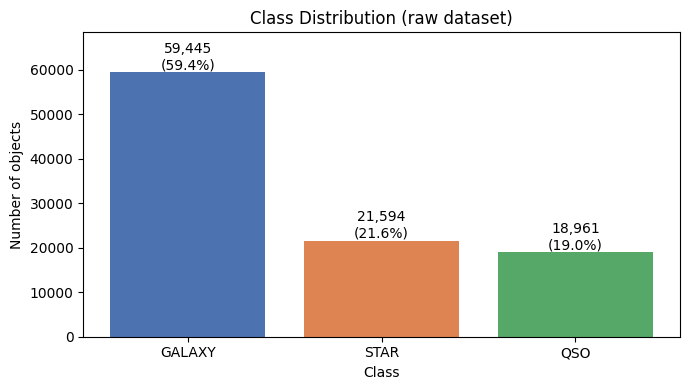

Imbalance ratio (majority / minority): 3.14x


In [3]:
# --- Class distribution (raw data) ---
counts = df_raw['class'].value_counts()
ratios = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values,
              color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title("Class Distribution (raw dataset)")
ax.set_ylabel("Number of objects")
ax.set_xlabel("Class")
for bar, c, p in zip(bars, counts.values, ratios.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{c:,}\n({p}%)", ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

print("Imbalance ratio (majority / minority): "
      f"{counts.max() / counts.min():.2f}x")

## V0 — Naive Baseline

This is the **starting point on purpose kept as bad as possible**, so later stages
have something to improve on. At this stage we deliberately do **not**:

- remove `-9999` sentinel (invalid measurement) values,
- drop ID / metadata columns — they are still used as features,
- scale features without leakage — the scaler is fit on the whole dataset,
- use a stratified train/test split,
- apply any class weighting.

**Expectation:** because ID columns (`obj_ID`, `run_ID`, `spec_obj_ID`, etc.) act as
near-unique identifiers, the models can "memorize" rows instead of learning physics.
This usually produces **artificially high scores** that will *drop* in V1 once the
leakage is removed — and that drop is exactly the point we want to demonstrate.

In [4]:
df_v0 = df_raw.copy()

# Target: class. Everything else is a feature (naive approach).
y_v0 = df_v0['class']
X_v0 = df_v0.drop(columns=['class'])

# Encode class string -> integer code
le = LabelEncoder()
y_v0_enc = le.fit_transform(y_v0)
print("Class encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
print("V0 feature count:", X_v0.shape[1])
print("V0 features:", list(X_v0.columns))

# Sentinel check — in V0 we only REPORT, we do NOT clean
print("\nSentinel (-9999) check:")
for col in X_v0.columns:
    n_bad = (X_v0[col] == -9999).sum()
    if n_bad > 0:
        print(f"  ! {col}: {n_bad} values of -9999 (left untouched in V0)")

Class encoding: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}
V0 feature count: 17
V0 features: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'redshift', 'plate', 'MJD', 'fiber_ID']

Sentinel (-9999) check:
  ! u: 1 values of -9999 (left untouched in V0)
  ! g: 1 values of -9999 (left untouched in V0)
  ! z: 1 values of -9999 (left untouched in V0)


### V0 — Train/Test Split & Scaling (the naive way)

Two deliberate mistakes are made here so that later stages can fix them:

1. **No stratification** — `train_test_split` is called without `stratify`, so the
   class proportions in train and test sets may drift apart. This matters because
   `QSO` is the minority class.
2. **Scaling with leakage** — the `StandardScaler` is fit on the **entire feature
   matrix** *before* splitting. This leaks information from the test set into
   training. The correct approach (a Pipeline that fits the scaler on training
   folds only) is introduced in V3.

In [5]:
# --- V0 split: NO stratification ---
X_train_v0, X_test_v0, y_train_v0, y_test_v0 = train_test_split(
    X_v0, y_v0_enc, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train_v0.shape, "| Test shape:", X_test_v0.shape)

# --- V0 scaling: LEAKAGE — scaler fit on the WHOLE feature matrix ---
scaler_v0 = StandardScaler()
X_all_scaled_v0 = scaler_v0.fit_transform(X_v0)          # fit on everything (wrong!)
X_train_scaled_v0 = scaler_v0.transform(X_train_v0)
X_test_scaled_v0  = scaler_v0.transform(X_test_v0)
print("Scaling done (fit on the full dataset — intentional leakage for V0).")

Train shape: (80000, 17) | Test shape: (20000, 17)
Scaling done (fit on the full dataset — intentional leakage for V0).


### V0 — Classical Machine Learning Models

Three classical models are trained: **Decision Tree**, **Random Forest**, and
**KNN**. No class weighting is used and accuracy is reported alongside macro-F1.
Tree models are fed the raw (unscaled) features, while KNN uses the scaled ones
since it is distance-based.

In [6]:
print("=== V0 — Classical ML ===")

# --- Decision Tree (no class_weight) ---
t0 = time.time()
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train_v0, y_train_v0)
pred = dt.predict(X_test_v0)
record("V0", "DecisionTree", y_test_v0, pred, time.time() - t0,
       notes="no cleaning, IDs kept")

# --- Random Forest (no class_weight) ---
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_v0, y_train_v0)
pred = rf.predict(X_test_v0)
record("V0", "RandomForest", y_test_v0, pred, time.time() - t0,
       notes="no cleaning, IDs kept")

# --- KNN (uses scaled features) ---
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_v0, y_train_v0)
pred = knn.predict(X_test_scaled_v0)
record("V0", "KNN", y_test_v0, pred, time.time() - t0,
       notes="leaky scaling, IDs kept")

=== V0 — Classical ML ===
  [V0] DecisionTree     | acc=0.9639 | f1_macro=0.9584 | f1_w=0.9639
  [V0] RandomForest     | acc=0.9787 | f1_macro=0.9751 | f1_w=0.9786
  [V0] KNN              | acc=0.8996 | f1_macro=0.8839 | f1_w=0.8981


{'version': 'V0',
 'model': 'KNN',
 'accuracy': 0.89965,
 'f1_macro': 0.8839443568991868,
 'f1_weighted': 0.8980503934043585,
 'cv_f1macro': nan,
 'train_time_s': 11.576485633850098,
 'notes': 'leaky scaling, IDs kept'}

### V0 — Gradient Boosting Models

**CatBoost** and **XGBoost** are strong gradient-boosting classifiers. At this
stage they also receive the raw feature set, including the ID columns.

In [7]:
# CatBoost & XGBoost — install if missing
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip -q install catboost
    from catboost import CatBoostClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip -q install xgboost
    from xgboost import XGBClassifier

print("=== V0 — Gradient Boosting ===")

# --- CatBoost ---
t0 = time.time()
cat = CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0)
cat.fit(X_train_v0, y_train_v0)
pred = cat.predict(X_test_v0).ravel()
record("V0", "CatBoost", y_test_v0, pred, time.time() - t0,
       notes="no cleaning, IDs kept")

# --- XGBoost ---
t0 = time.time()
xgb = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                    eval_metric="mlogloss", n_jobs=-1)
xgb.fit(X_train_v0, y_train_v0)
pred = xgb.predict(X_test_v0)
record("V0", "XGBoost", y_test_v0, pred, time.time() - t0,
       notes="no cleaning, IDs kept")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
=== V0 — Gradient Boosting ===
  [V0] CatBoost         | acc=0.9777 | f1_macro=0.9740 | f1_w=0.9776
  [V0] XGBoost          | acc=0.9771 | f1_macro=0.9735 | f1_w=0.9770


{'version': 'V0',
 'model': 'XGBoost',
 'accuracy': 0.9771,
 'f1_macro': 0.97352323631383,
 'f1_weighted': 0.9769846717310194,
 'cv_f1macro': nan,
 'train_time_s': 8.695979356765747,
 'notes': 'no cleaning, IDs kept'}

### V0 — Deep Learning Models

Three neural networks are trained with TensorFlow/Keras: an **MLP**
(fully-connected), a **1D CNN**, and an **LSTM**. They all use the
leaky-scaled features from V0, with no class weighting and a non-stratified
validation split. Deep models are sensitive to feature scale, so they receive
the scaled feature matrix.

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)

print("=== V0 — Deep Learning ===")

n_features = X_train_scaled_v0.shape[1]
n_classes  = len(le.classes_)

# Non-stratified validation split (carved out of the training set)
val_split = 0.2

def make_mlp(input_dim, n_classes):
    m = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

def make_cnn(input_dim, n_classes):
    m = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(32, 2, activation="relu", padding="same"),
        layers.Conv1D(64, 2, activation="relu", padding="same"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

def make_lstm(input_dim, n_classes):
    m = models.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# --- MLP ---
t0 = time.time()
mlp = make_mlp(n_features, n_classes)
mlp.fit(X_train_scaled_v0, y_train_v0, validation_split=val_split,
        epochs=50, batch_size=256, callbacks=[early], verbose=0)
pred = mlp.predict(X_test_scaled_v0, verbose=0).argmax(axis=1)
record("V0", "MLP", y_test_v0, pred, time.time() - t0,
       notes="leaky scaling, IDs kept")

# --- 1D CNN ---
t0 = time.time()
X_tr_cnn = X_train_scaled_v0.reshape(-1, n_features, 1)
X_te_cnn = X_test_scaled_v0.reshape(-1, n_features, 1)
cnn = make_cnn(n_features, n_classes)
cnn.fit(X_tr_cnn, y_train_v0, validation_split=val_split,
        epochs=50, batch_size=256, callbacks=[early], verbose=0)
pred = cnn.predict(X_te_cnn, verbose=0).argmax(axis=1)
record("V0", "CNN_1D", y_test_v0, pred, time.time() - t0,
       notes="leaky scaling, IDs kept")

# --- LSTM ---
t0 = time.time()
lstm = make_lstm(n_features, n_classes)
lstm.fit(X_tr_cnn, y_train_v0, validation_split=val_split,
         epochs=50, batch_size=256, callbacks=[early], verbose=0)
pred = lstm.predict(X_te_cnn, verbose=0).argmax(axis=1)
record("V0", "LSTM", y_test_v0, pred, time.time() - t0,
       notes="leaky scaling, IDs kept")

=== V0 — Deep Learning ===
  [V0] MLP              | acc=0.9672 | f1_macro=0.9628 | f1_w=0.9671
  [V0] CNN_1D           | acc=0.6744 | f1_macro=0.4825 | f1_w=0.5906
  [V0] LSTM             | acc=0.6801 | f1_macro=0.5210 | f1_w=0.6136


{'version': 'V0',
 'model': 'LSTM',
 'accuracy': 0.68005,
 'f1_macro': 0.5210123754098526,
 'f1_weighted': 0.6136020928434472,
 'cv_f1macro': nan,
 'train_time_s': 68.10553741455078,
 'notes': 'leaky scaling, IDs kept'}

In [9]:
# V0 summary table
v0_df = pd.DataFrame([r for r in all_results if r["version"] == "V0"])
print("=== V0 — Summary (all 8 models) ===")
print(v0_df[["model", "accuracy", "f1_macro", "f1_weighted", "train_time_s"]]
      .round(4).to_string(index=False))

=== V0 — Summary (all 8 models) ===
       model  accuracy  f1_macro  f1_weighted  train_time_s
DecisionTree    0.9639    0.9584       0.9639        3.7930
RandomForest    0.9787    0.9751       0.9786       42.5533
         KNN    0.8996    0.8839       0.8981       11.5765
    CatBoost    0.9777    0.9740       0.9776       10.0646
     XGBoost    0.9771    0.9735       0.9770        8.6960
         MLP    0.9672    0.9628       0.9671       71.3492
      CNN_1D    0.6744    0.4825       0.5906       20.5317
        LSTM    0.6800    0.5210       0.6136       68.1055


## V1 — Data Cleaning

The first real improvement. Two cleaning steps are applied:

1. **Sentinel removal** — some photometric bands contain `-9999`, a placeholder
   for *invalid / failed measurements*. These are not real values, so rows
   containing them are dropped.
2. **Dropping ID & metadata columns** — columns such as `obj_ID`, `run_ID`,
   `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID`
   are identifiers or observation metadata, **not physical properties** of the
   object. In V0 the models were able to *memorize* rows through these
   near-unique IDs, which inflated the scores.

**Expectation:** the tree/boosting models will likely **drop** from their V0
scores, because the artificial "memorization" signal is now gone. This drop is a
*good* sign — it means the remaining performance reflects real astrophysical
learning. The deep models (CNN/LSTM) should instead **improve**, since the huge
ID values that dominated their input are removed.

Everything else (leaky scaling, no stratification, no class weighting) is still
kept naive — those are fixed in later stages.

In [10]:
# ============================================================
# V1 — DATA CLEANING
# (1) drop rows with -9999 sentinel values
# (2) drop ID / metadata columns
# Still naive: leaky scaling, no stratification, no class_weight.
# ============================================================

df_v1 = df_raw.copy()

# --- (1) Remove sentinel -9999 rows ---
sentinel_mask = (df_v1 == -9999).any(axis=1)
print(f"Rows with -9999 sentinel: {sentinel_mask.sum()}")
df_v1 = df_v1[~sentinel_mask].reset_index(drop=True)
print(f"Shape after sentinel removal: {df_v1.shape}")

# --- (2) Drop ID / metadata columns ---
id_meta_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
                'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
# keep only those that actually exist in the dataframe
id_meta_cols = [c for c in id_meta_cols if c in df_v1.columns]
print(f"Dropping ID/metadata columns: {id_meta_cols}")

y_v1 = df_v1['class']
X_v1 = df_v1.drop(columns=['class'] + id_meta_cols)

y_v1_enc = le.transform(y_v1)   # reuse the same LabelEncoder from V0

print("V1 feature count:", X_v1.shape[1])
print("V1 features:", list(X_v1.columns))

Rows with -9999 sentinel: 1
Shape after sentinel removal: (99999, 18)
Dropping ID/metadata columns: ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
V1 feature count: 8
V1 features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


### V1 — Split, Scaling & Model Training

The split and scaling are still done the **naive way** (leaky scaling, no
stratification, no class weighting) — exactly as in V0. The *only* thing that
changed since V0 is the cleaned feature set. This isolation is intentional: it
guarantees that any score difference comes purely from the data cleaning step.

In [11]:
# ============================================================
# V1 — same naive split/scaling as V0, only the data changed
# ============================================================

# --- Split: still NO stratification ---
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1_enc, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train_v1.shape, "| Test:", X_test_v1.shape)

# --- Scaling: still LEAKY (fit on the whole matrix) ---
scaler_v1 = StandardScaler()
scaler_v1.fit(X_v1)
X_train_scaled_v1 = scaler_v1.transform(X_train_v1)
X_test_scaled_v1  = scaler_v1.transform(X_test_v1)

n_features = X_train_scaled_v1.shape[1]
n_classes  = len(le.classes_)

# ---------- Classical ML ----------
print("\n=== V1 — Classical ML ===")

t0 = time.time()
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train_v1, y_train_v1)
record("V1", "DecisionTree", y_test_v1, dt.predict(X_test_v1),
       time.time() - t0, notes="cleaned data, leaky scaling")

t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_v1, y_train_v1)
record("V1", "RandomForest", y_test_v1, rf.predict(X_test_v1),
       time.time() - t0, notes="cleaned data, leaky scaling")

t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_v1, y_train_v1)
record("V1", "KNN", y_test_v1, knn.predict(X_test_scaled_v1),
       time.time() - t0, notes="cleaned data, leaky scaling")

# ---------- Gradient Boosting ----------
print("\n=== V1 — Gradient Boosting ===")

t0 = time.time()
cat = CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0)
cat.fit(X_train_v1, y_train_v1)
record("V1", "CatBoost", y_test_v1, cat.predict(X_test_v1).ravel(),
       time.time() - t0, notes="cleaned data, leaky scaling")

t0 = time.time()
xgb = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                    eval_metric="mlogloss", n_jobs=-1)
xgb.fit(X_train_v1, y_train_v1)
record("V1", "XGBoost", y_test_v1, xgb.predict(X_test_v1),
       time.time() - t0, notes="cleaned data, leaky scaling")

# ---------- Deep Learning ----------
print("\n=== V1 — Deep Learning ===")
tf.random.set_seed(RANDOM_STATE)
early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
val_split = 0.2

# MLP
t0 = time.time()
mlp = make_mlp(n_features, n_classes)
mlp.fit(X_train_scaled_v1, y_train_v1, validation_split=val_split,
        epochs=50, batch_size=256, callbacks=[early], verbose=0)
record("V1", "MLP", y_test_v1,
       mlp.predict(X_test_scaled_v1, verbose=0).argmax(axis=1),
       time.time() - t0, notes="cleaned data, leaky scaling")

# 1D CNN
t0 = time.time()
X_tr_cnn = X_train_scaled_v1.reshape(-1, n_features, 1)
X_te_cnn = X_test_scaled_v1.reshape(-1, n_features, 1)
cnn = make_cnn(n_features, n_classes)
cnn.fit(X_tr_cnn, y_train_v1, validation_split=val_split,
        epochs=50, batch_size=256, callbacks=[early], verbose=0)
record("V1", "CNN_1D", y_test_v1,
       cnn.predict(X_te_cnn, verbose=0).argmax(axis=1),
       time.time() - t0, notes="cleaned data, leaky scaling")

# LSTM
t0 = time.time()
lstm = make_lstm(n_features, n_classes)
lstm.fit(X_tr_cnn, y_train_v1, validation_split=val_split,
         epochs=50, batch_size=256, callbacks=[early], verbose=0)
record("V1", "LSTM", y_test_v1,
       lstm.predict(X_te_cnn, verbose=0).argmax(axis=1),
       time.time() - t0, notes="cleaned data, leaky scaling")

Train: (79999, 8) | Test: (20000, 8)

=== V1 — Classical ML ===
  [V1] DecisionTree     | acc=0.9646 | f1_macro=0.9592 | f1_w=0.9646
  [V1] RandomForest     | acc=0.9772 | f1_macro=0.9734 | f1_w=0.9771
  [V1] KNN              | acc=0.9388 | f1_macro=0.9319 | f1_w=0.9388

=== V1 — Gradient Boosting ===
  [V1] CatBoost         | acc=0.9759 | f1_macro=0.9720 | f1_w=0.9758
  [V1] XGBoost          | acc=0.9748 | f1_macro=0.9710 | f1_w=0.9747

=== V1 — Deep Learning ===
  [V1] MLP              | acc=0.9696 | f1_macro=0.9654 | f1_w=0.9694
  [V1] CNN_1D           | acc=0.9305 | f1_macro=0.9229 | f1_w=0.9306
  [V1] LSTM             | acc=0.9323 | f1_macro=0.9242 | f1_w=0.9320


{'version': 'V1',
 'model': 'LSTM',
 'accuracy': 0.93225,
 'f1_macro': 0.9241982177055802,
 'f1_weighted': 0.9319507422022227,
 'cv_f1macro': nan,
 'train_time_s': 41.695438385009766,
 'notes': 'cleaned data, leaky scaling'}

In [12]:
# V1 summary + comparison vs V0
v1_df = pd.DataFrame([r for r in all_results if r["version"] == "V1"])
print("=== V1 — Summary (all 8 models) ===")
print(v1_df[["model", "accuracy", "f1_macro", "f1_weighted", "train_time_s"]]
      .round(4).to_string(index=False))

# Delta vs V0
v0_df = pd.DataFrame([r for r in all_results if r["version"] == "V0"])
cmp = v0_df[["model", "f1_macro"]].merge(
    v1_df[["model", "f1_macro"]], on="model", suffixes=("_V0", "_V1"))
cmp["delta"] = (cmp["f1_macro_V1"] - cmp["f1_macro_V0"]).round(4)
print("\n=== F1-macro change: V0 -> V1 ===")
print(cmp.round(4).to_string(index=False))

=== V1 — Summary (all 8 models) ===
       model  accuracy  f1_macro  f1_weighted  train_time_s
DecisionTree    0.9646    0.9592       0.9646        5.4643
RandomForest    0.9772    0.9734       0.9771       63.4524
         KNN    0.9388    0.9319       0.9388        1.6934
    CatBoost    0.9759    0.9720       0.9758        7.6951
     XGBoost    0.9748    0.9710       0.9747        7.0134
         MLP    0.9696    0.9654       0.9694       66.6147
      CNN_1D    0.9306    0.9229       0.9306       17.7078
        LSTM    0.9322    0.9242       0.9320       41.6954

=== F1-macro change: V0 -> V1 ===
       model  f1_macro_V0  f1_macro_V1   delta
DecisionTree       0.9584       0.9592  0.0008
RandomForest       0.9751       0.9734 -0.0017
         KNN       0.8839       0.9319  0.0479
    CatBoost       0.9740       0.9720 -0.0021
     XGBoost       0.9735       0.9710 -0.0026
         MLP       0.9628       0.9654  0.0026
      CNN_1D       0.4825       0.9229  0.4404
        LSTM 

### Feature Correlations — Motivating Color Indices

This heatmap is shown **before V2** on purpose: it explains *why* color indices
are worth engineering.

The five photometric bands (`u`, `g`, `r`, `i`, `z`) all measure brightness, so
they are expected to be **highly correlated** with each other — a bright object
tends to be bright in every band. Highly correlated raw features carry redundant
information.

A **color index** (the difference between two bands, e.g. `u - g`) removes this
shared "overall brightness" component and keeps only the part that describes the
*shape of the spectrum* — which is what actually separates stars, galaxies and
quasars. The correlation matrix below makes the redundancy visible and motivates
the V2 feature engineering step.

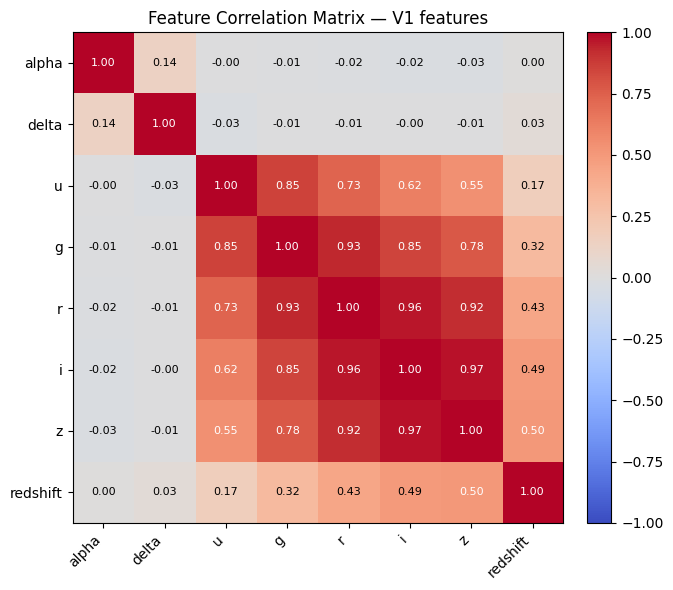

Mean correlation among photometric bands (u,g,r,i,z): 0.816


In [13]:
# --- Correlation matrix on the cleaned V1 features (no color indices yet) ---
corr = X_v1.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_title("Feature Correlation Matrix — V1 features")

# annotate each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black',
                fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# highlight the strong band-band correlations
bands = ['u', 'g', 'r', 'i', 'z']
band_corr = X_v1[bands].corr()
print("Mean correlation among photometric bands (u,g,r,i,z): "
      f"{band_corr.values[np.triu_indices(5, k=1)].mean():.3f}")

### Redshift Distribution by Class

Redshift measures how much an object's light is stretched by cosmic expansion —
it is closely tied to distance and object type. Plotting its distribution
separately for each class shows how strongly this single feature separates them:

- **STAR** — redshift ≈ 0 (stars are inside our own galaxy).
- **GALAXY** — small positive redshift.
- **QSO (quasar)** — much larger redshift (quasars are extremely distant).

This plot foreshadows two later findings: redshift will dominate the **feature
importance** ranking (V3), and the minority class **QSO** will be classified well
even *before* class balancing (V4), simply because redshift makes it easy to
separate.

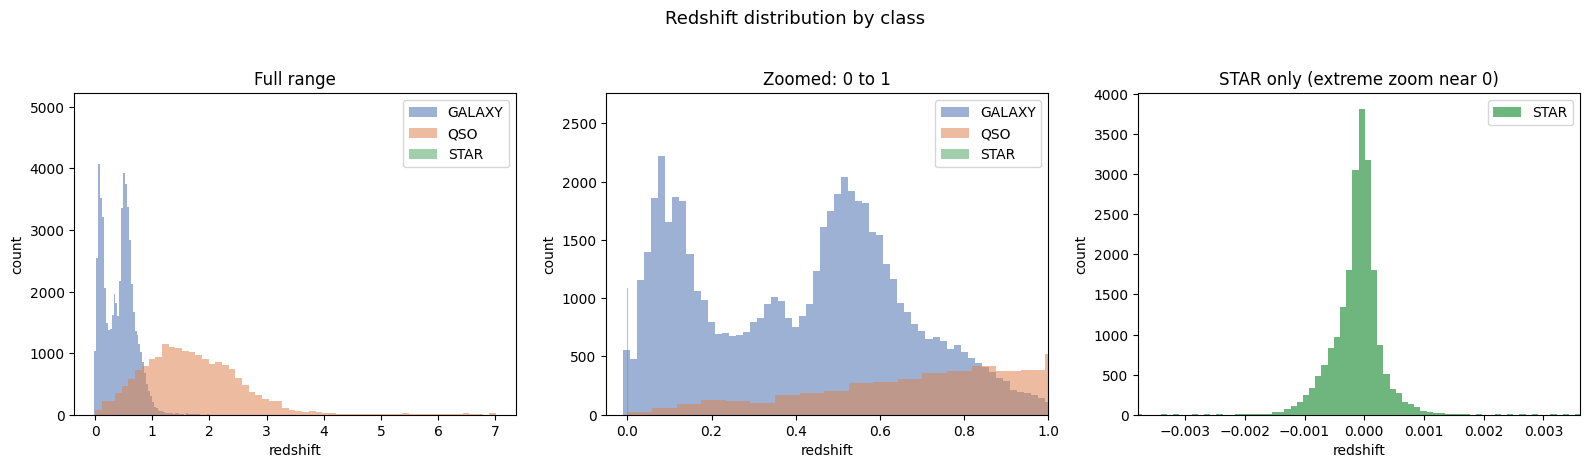

Redshift summary by class:
  STAR    median=-0.00008 | mean=-0.00011 | min=-0.00414 | max=0.00415
  GALAXY  median=0.45627 | mean=0.42160 | min=-0.00997 | max=1.99552
  QSO     median=1.61723 | mean=1.71968 | min=0.00046 | max=7.01124


In [14]:
# --- Redshift distribution by class (cleaned V1 data) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}

# (left) full range — draw STAR last with a clear edge so it is not hidden
for cls in ['GALAXY', 'QSO', 'STAR']:
    vals = df_v1.loc[df_v1['class'] == cls, 'redshift']
    axes[0].hist(vals, bins=60, alpha=0.55, label=cls, color=colors[cls])
axes[0].set_title("Full range")
axes[0].set_xlabel("redshift"); axes[0].set_ylabel("count")
axes[0].legend()

# (middle) zoomed to 0–1 — STAR and GALAXY region
for cls in ['GALAXY', 'QSO', 'STAR']:
    vals = df_v1.loc[df_v1['class'] == cls, 'redshift']
    axes[1].hist(vals, bins=120, alpha=0.55, label=cls, color=colors[cls])
axes[1].set_xlim(-0.05, 1.0)
axes[1].set_title("Zoomed: 0 to 1")
axes[1].set_xlabel("redshift"); axes[1].set_ylabel("count")
axes[1].legend()

# (right) STAR only — extreme zoom near 0, so it is clearly visible
star_vals = df_v1.loc[df_v1['class'] == 'STAR', 'redshift']
axes[2].hist(star_vals, bins=80, color=colors['STAR'], alpha=0.85, label='STAR')
axes[2].set_xlim(star_vals.quantile(0.001), star_vals.quantile(0.999))
axes[2].set_title("STAR only (extreme zoom near 0)")
axes[2].set_xlabel("redshift"); axes[2].set_ylabel("count")
axes[2].legend()

plt.suptitle("Redshift distribution by class", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# numeric summary
print("Redshift summary by class:")
for cls in ['STAR', 'GALAXY', 'QSO']:
    vals = df_v1.loc[df_v1['class'] == cls, 'redshift']
    print(f"  {cls:7s} median={vals.median():.5f} | mean={vals.mean():.5f} | "
          f"min={vals.min():.5f} | max={vals.max():.5f}")

## V2 — Feature Engineering: Color Indices

This stage adds **domain-specific engineered features**. In astronomy, the
*absolute* brightness of an object in a single band (u, g, r, i, z) is less
informative than the **difference between two bands** — called a *color index*.
Color indices capture the *shape of the spectrum*, which is strongly tied to an
object's physical type and is largely independent of its distance.

Four standard color indices are added:

- **u - g**
- **g - r**
- **r - i**
- **i - z**

These follow the wavelength ordering of the SDSS photometric system.

**Expectation:** a small but consistent improvement in macro-F1, and a more
noticeable gain on the minority class (`QSO`), since color is one of the main
ways quasars are distinguished from stars and galaxies.

Everything else is still kept as in V1 (leaky scaling, no stratification, no
class weighting) so the gain is attributable purely to feature engineering.

In [15]:
# ============================================================
# V2 — FEATURE ENGINEERING (color indices)
# Start from the V1 cleaned data, then add 4 color-index features.
# Still naive: leaky scaling, no stratification, no class_weight.
# ============================================================

df_v2 = df_v1.copy()   # already cleaned (sentinels removed)

# Add color indices (wavelength order: u, g, r, i, z)
df_v2['u_g'] = df_v2['u'] - df_v2['g']
df_v2['g_r'] = df_v2['g'] - df_v2['r']
df_v2['r_i'] = df_v2['r'] - df_v2['i']
df_v2['i_z'] = df_v2['i'] - df_v2['z']

y_v2 = df_v2['class']
X_v2 = df_v2.drop(columns=['class'] + id_meta_cols)

y_v2_enc = le.transform(y_v2)

print("V2 feature count:", X_v2.shape[1], "(V1 had", X_v1.shape[1], ")")
print("V2 features:", list(X_v2.columns))

V2 feature count: 12 (V1 had 8 )
V2 features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']


### V2 — Split, Scaling & Model Training

The split and scaling stay naive (leaky scaling, no stratification, no class
weighting), identical to V1. The only change since V1 is the four added color
indices, so any score difference is attributable purely to feature engineering.

In [16]:
# ============================================================
# V2 — same naive split/scaling as V1, only color indices added
# ============================================================

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2_enc, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train_v2.shape, "| Test:", X_test_v2.shape)

# Leaky scaling (fit on the whole matrix), same as V1
scaler_v2 = StandardScaler()
scaler_v2.fit(X_v2)
X_train_scaled_v2 = scaler_v2.transform(X_train_v2)
X_test_scaled_v2  = scaler_v2.transform(X_test_v2)

n_features = X_train_scaled_v2.shape[1]
n_classes  = len(le.classes_)

# ---------- Classical ML ----------
print("\n=== V2 — Classical ML ===")

t0 = time.time()
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train_v2, y_train_v2)
record("V2", "DecisionTree", y_test_v2, dt.predict(X_test_v2),
       time.time() - t0, notes="cleaned + color indices")

t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_v2, y_train_v2)
record("V2", "RandomForest", y_test_v2, rf.predict(X_test_v2),
       time.time() - t0, notes="cleaned + color indices")

t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_v2, y_train_v2)
record("V2", "KNN", y_test_v2, knn.predict(X_test_scaled_v2),
       time.time() - t0, notes="cleaned + color indices")

# ---------- Gradient Boosting ----------
print("\n=== V2 — Gradient Boosting ===")

t0 = time.time()
cat = CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0)
cat.fit(X_train_v2, y_train_v2)
record("V2", "CatBoost", y_test_v2, cat.predict(X_test_v2).ravel(),
       time.time() - t0, notes="cleaned + color indices")

t0 = time.time()
xgb = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                    eval_metric="mlogloss", n_jobs=-1)
xgb.fit(X_train_v2, y_train_v2)
record("V2", "XGBoost", y_test_v2, xgb.predict(X_test_v2),
       time.time() - t0, notes="cleaned + color indices")

# ---------- Deep Learning ----------
print("\n=== V2 — Deep Learning ===")
tf.random.set_seed(RANDOM_STATE)
early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
val_split = 0.2

# MLP
t0 = time.time()
mlp = make_mlp(n_features, n_classes)
mlp.fit(X_train_scaled_v2, y_train_v2, validation_split=val_split,
        epochs=50, batch_size=256, callbacks=[early], verbose=0)
record("V2", "MLP", y_test_v2,
       mlp.predict(X_test_scaled_v2, verbose=0).argmax(axis=1),
       time.time() - t0, notes="cleaned + color indices")

# 1D CNN
t0 = time.time()
X_tr_cnn = X_train_scaled_v2.reshape(-1, n_features, 1)
X_te_cnn = X_test_scaled_v2.reshape(-1, n_features, 1)
cnn = make_cnn(n_features, n_classes)
cnn.fit(X_tr_cnn, y_train_v2, validation_split=val_split,
        epochs=50, batch_size=256, callbacks=[early], verbose=0)
record("V2", "CNN_1D", y_test_v2,
       cnn.predict(X_te_cnn, verbose=0).argmax(axis=1),
       time.time() - t0, notes="cleaned + color indices")

# LSTM
t0 = time.time()
lstm = make_lstm(n_features, n_classes)
lstm.fit(X_tr_cnn, y_train_v2, validation_split=val_split,
         epochs=50, batch_size=256, callbacks=[early], verbose=0)
record("V2", "LSTM", y_test_v2,
       lstm.predict(X_te_cnn, verbose=0).argmax(axis=1),
       time.time() - t0, notes="cleaned + color indices")

Train: (79999, 12) | Test: (20000, 12)

=== V2 — Classical ML ===
  [V2] DecisionTree     | acc=0.9660 | f1_macro=0.9608 | f1_w=0.9660
  [V2] RandomForest     | acc=0.9778 | f1_macro=0.9741 | f1_w=0.9776
  [V2] KNN              | acc=0.9446 | f1_macro=0.9378 | f1_w=0.9446

=== V2 — Gradient Boosting ===
  [V2] CatBoost         | acc=0.9775 | f1_macro=0.9739 | f1_w=0.9774
  [V2] XGBoost          | acc=0.9757 | f1_macro=0.9719 | f1_w=0.9756

=== V2 — Deep Learning ===
  [V2] MLP              | acc=0.9692 | f1_macro=0.9651 | f1_w=0.9691
  [V2] CNN_1D           | acc=0.8197 | f1_macro=0.7684 | f1_w=0.8088
  [V2] LSTM             | acc=0.8603 | f1_macro=0.8353 | f1_w=0.8567


{'version': 'V2',
 'model': 'LSTM',
 'accuracy': 0.8603,
 'f1_macro': 0.8352891583403887,
 'f1_weighted': 0.856715822866996,
 'cv_f1macro': nan,
 'train_time_s': 43.71001124382019,
 'notes': 'cleaned + color indices'}

In [17]:
# V2 summary + comparison vs V1
v2_df = pd.DataFrame([r for r in all_results if r["version"] == "V2"])
print("=== V2 — Summary (all 8 models) ===")
print(v2_df[["model", "accuracy", "f1_macro", "f1_weighted", "train_time_s"]]
      .round(4).to_string(index=False))

# Delta vs V1
v1_df = pd.DataFrame([r for r in all_results if r["version"] == "V1"])
cmp = v1_df[["model", "f1_macro"]].merge(
    v2_df[["model", "f1_macro"]], on="model", suffixes=("_V1", "_V2"))
cmp["delta"] = (cmp["f1_macro_V2"] - cmp["f1_macro_V1"]).round(4)
print("\n=== F1-macro change: V1 -> V2 ===")
print(cmp.round(4).to_string(index=False))

=== V2 — Summary (all 8 models) ===
       model  accuracy  f1_macro  f1_weighted  train_time_s
DecisionTree    0.9660    0.9608       0.9660        4.2055
RandomForest    0.9778    0.9741       0.9776       48.3126
         KNN    0.9446    0.9378       0.9446        5.1993
    CatBoost    0.9775    0.9739       0.9774       10.1116
     XGBoost    0.9757    0.9719       0.9756        6.1632
         MLP    0.9692    0.9651       0.9691       40.5471
      CNN_1D    0.8197    0.7684       0.8088       17.4294
        LSTM    0.8603    0.8353       0.8567       43.7100

=== F1-macro change: V1 -> V2 ===
       model  f1_macro_V1  f1_macro_V2   delta
DecisionTree       0.9592       0.9608  0.0016
RandomForest       0.9734       0.9741  0.0007
         KNN       0.9319       0.9378  0.0059
    CatBoost       0.9720       0.9739  0.0019
     XGBoost       0.9710       0.9719  0.0010
         MLP       0.9654       0.9651 -0.0003
      CNN_1D       0.9229       0.7684 -0.1545
        LSTM 

### Color–Color Diagram

This scatter plot is the classic astronomical diagnostic and is shown **after
V2**, because it uses the color indices engineered in that stage. It plots two
color indices against each other — `u-g` versus `g-r` — with points colored by
class.

If the three classes occupy **distinct regions** of this color space, it
visually confirms that color indices carry real class-separating information,
and therefore that the V2 feature engineering step was worthwhile — independent
of the dominant `redshift` feature.

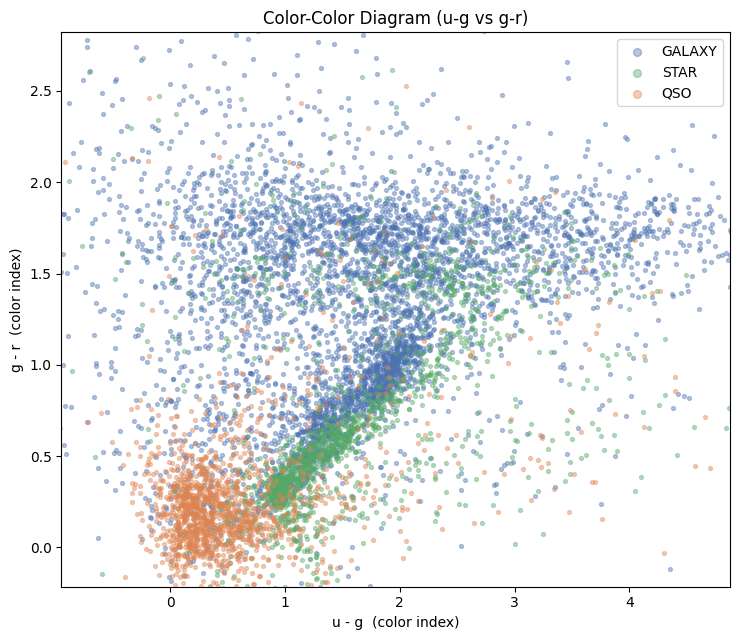

Mean color indices by class:
  STAR    u-g=1.537 | g-r=0.670 | r-i=0.403 | i-z=0.209
  GALAXY  u-g=1.681 | g-r=1.319 | r-i=0.736 | i-z=0.403
  QSO     u-g=0.621 | g-r=0.302 | r-i=0.193 | i-z=0.164


In [18]:
# --- Color-color diagram: u-g vs g-r, colored by class (V2 data) ---
fig, ax = plt.subplots(figsize=(7.5, 6.5))
colors = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}

# subsample for a readable plot (100k points would be an unreadable blob)
plot_df = df_v2.sample(n=min(8000, len(df_v2)), random_state=RANDOM_STATE)

for cls in ['GALAXY', 'STAR', 'QSO']:
    sub = plot_df[plot_df['class'] == cls]
    ax.scatter(sub['u_g'], sub['g_r'], s=8, alpha=0.4,
               label=cls, color=colors[cls])

ax.set_xlabel("u - g  (color index)")
ax.set_ylabel("g - r  (color index)")
ax.set_title("Color-Color Diagram (u-g vs g-r)")
# clip extreme outliers so the main cloud is visible
ax.set_xlim(plot_df['u_g'].quantile(0.01), plot_df['u_g'].quantile(0.99))
ax.set_ylim(plot_df['g_r'].quantile(0.01), plot_df['g_r'].quantile(0.99))
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

# numeric: mean color per class
print("Mean color indices by class:")
for cls in ['STAR', 'GALAXY', 'QSO']:
    sub = df_v2[df_v2['class'] == cls]
    print(f"  {cls:7s} u-g={sub['u_g'].mean():.3f} | g-r={sub['g_r'].mean():.3f} | "
          f"r-i={sub['r_i'].mean():.3f} | i-z={sub['i_z'].mean():.3f}")

## V3 — Fixing Data Leakage & Stratification

Up to V2, two methodological flaws were deliberately kept:

1. **Leaky scaling** — the `StandardScaler` was fit on the *entire* feature
   matrix, so statistics from the test set leaked into training.
2. **No stratification** — train/test splits ignored class proportions, which is
   risky for the minority class `QSO`.

V3 fixes both:

- **Scaling inside a `Pipeline`** — the scaler is now fit *only* on the training
  data of each split/fold, never on the test set. For models that need scaling
  (KNN, deep nets) this removes the leakage.
- **Stratified split** — `train_test_split(..., stratify=y)` keeps the same class
  ratios in train and test.
- **Stratified 5-fold cross-validation** — classical ML models are now evaluated
  with `StratifiedKFold` cross-validation, giving a mean macro-F1 *and* its
  standard deviation, instead of a single (possibly lucky) test score.

**Expectation:** the single test scores may move only slightly, but the results
become **trustworthy**. The cross-validation std shows how stable each model is.
Deep models also benefit from leakage-free scaling.

Class weighting is still *not* applied — that is the final step, V4.

In [19]:
# ============================================================
# V3 — LEAKAGE FIX + STRATIFICATION
# Same features as V2 (cleaned + color indices).
# Changes: scaling moved into a Pipeline (fit on train only),
#          stratified split, stratified 5-fold CV.
# ============================================================

# Reuse the V2 feature matrix (cleaned + color indices)
X_v3 = X_v2.copy()
y_v3_enc = y_v2_enc.copy()

# --- Stratified split ---
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3_enc, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y_v3_enc
)
print("Train:", X_train_v3.shape, "| Test:", X_test_v3.shape)

# Check that class ratios match between train and test
for name, yy in [("Full", y_v3_enc), ("Train", y_train_v3), ("Test", y_test_v3)]:
    vals, cnts = np.unique(yy, return_counts=True)
    ratios = (cnts / cnts.sum()).round(4)
    print(f"  {name:6s} class ratios:", dict(zip(le.classes_, ratios)))

# Stratified CV object reused by all classical models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: (79999, 12) | Test: (20000, 12)
  Full   class ratios: {'GALAXY': np.float64(0.5945), 'QSO': np.float64(0.1896), 'STAR': np.float64(0.2159)}
  Train  class ratios: {'GALAXY': np.float64(0.5945), 'QSO': np.float64(0.1896), 'STAR': np.float64(0.2159)}
  Test   class ratios: {'GALAXY': np.float64(0.5944), 'QSO': np.float64(0.1896), 'STAR': np.float64(0.216)}


### V3 — Leakage-Free Training & Cross-Validation

Classical models are now wrapped in a `Pipeline(StandardScaler -> model)`. This
guarantees the scaler is fit only on training data — both in the final fit and
inside every cross-validation fold. Each classical model reports:

- a **test macro-F1** (single hold-out test set), and
- a **5-fold stratified CV macro-F1 mean ± std**, showing stability.

Tree-based models technically do not need scaling, but using the same Pipeline
for all models keeps the procedure uniform and harmless.

Deep models receive a scaler that is fit on the **training set only** (no
leakage), unlike V0–V2 where it was fit on the whole matrix.

In [20]:
# ============================================================
# V3 — Classical ML with Pipeline (leakage-free) + Stratified CV
# ============================================================
print("=== V3 — Classical ML (Pipeline + 5-fold Stratified CV) ===")

def run_classical_v3(name, estimator, notes):
    """Fit a Pipeline, evaluate on test set, and run stratified CV."""
    pipe = Pipeline([("scaler", StandardScaler()), ("model", estimator)])

    # 5-fold stratified CV on the training set (macro-F1)
    t0 = time.time()
    cv = cross_validate(pipe, X_train_v3, y_train_v3, cv=skf,
                        scoring="f1_macro", n_jobs=-1)
    cv_mean, cv_std = cv["test_score"].mean(), cv["test_score"].std()

    # Final fit on full training set, evaluate on hold-out test set
    pipe.fit(X_train_v3, y_train_v3)
    pred = pipe.predict(X_test_v3)
    train_time = time.time() - t0

    record("V3", name, y_test_v3, pred, train_time,
           cv_f1macro=cv_mean, notes=notes)
    print(f"      CV macro-F1: {cv_mean:.4f} +/- {cv_std:.4f}")

run_classical_v3("DecisionTree",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    "pipeline + stratified CV")

run_classical_v3("RandomForest",
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "pipeline + stratified CV")

run_classical_v3("KNN",
    KNeighborsClassifier(n_neighbors=5),
    "pipeline + stratified CV")

run_classical_v3("CatBoost",
    CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0),
    "pipeline + stratified CV")

run_classical_v3("XGBoost",
    XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                  eval_metric="mlogloss", n_jobs=-1),
    "pipeline + stratified CV")

=== V3 — Classical ML (Pipeline + 5-fold Stratified CV) ===
  [V3] DecisionTree     | acc=0.9681 | f1_macro=0.9632 | f1_w=0.9681
      CV macro-F1: 0.9590 +/- 0.0013
  [V3] RandomForest     | acc=0.9798 | f1_macro=0.9765 | f1_w=0.9797
      CV macro-F1: 0.9749 +/- 0.0015
  [V3] KNN              | acc=0.9444 | f1_macro=0.9381 | f1_w=0.9443
      CV macro-F1: 0.9368 +/- 0.0020
  [V3] CatBoost         | acc=0.9770 | f1_macro=0.9735 | f1_w=0.9769
      CV macro-F1: 0.9746 +/- 0.0019
  [V3] XGBoost          | acc=0.9773 | f1_macro=0.9738 | f1_w=0.9772
      CV macro-F1: 0.9729 +/- 0.0012


In [21]:
# ============================================================
# FIX: stratified validation split for all deep-learning models
# Step 1 — remove old (validation_split) DL results for V3/V4/V5
# Step 2 — define a helper that uses a STRATIFIED validation split
#
# Keras' validation_split takes the LAST 20% of the training data without
# shuffling or stratification. With an imbalanced dataset this gives
# EarlyStopping a biased validation set. The helper below builds the
# validation set with a stratified split instead.
# ============================================================
dl_models = {"MLP", "CNN_1D", "LSTM"}
fix_versions = {"V3", "V4", "V5"}

before = len(all_results)
all_results = [r for r in all_results
               if not (r["version"] in fix_versions and r["model"] in dl_models)]
print(f"Removed {before - len(all_results)} old DL rows (V3/V4/V5).")

def fit_dl_stratified(builder, X_train_scaled, y_train, X_test_scaled,
                      sequence=False, class_weight=None):
    """Train a Keras model using a STRATIFIED validation split."""
    n_feat = X_train_scaled.shape[1]
    n_cls  = len(le.classes_)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.2,
        random_state=RANDOM_STATE, stratify=y_train
    )
    if sequence:
        X_tr  = X_tr.reshape(-1, n_feat, 1)
        X_val = X_val.reshape(-1, n_feat, 1)
        X_te  = X_test_scaled.reshape(-1, n_feat, 1)
    else:
        X_te  = X_test_scaled

    early = EarlyStopping(monitor="val_loss", patience=5,
                          restore_best_weights=True)
    model = builder(n_feat, n_cls)
    model.fit(X_tr, y_tr,
              validation_data=(X_val, y_val),
              epochs=50, batch_size=256, callbacks=[early],
              class_weight=class_weight, verbose=0)
    return model.predict(X_te, verbose=0).argmax(axis=1)

Removed 0 old DL rows (V3/V4/V5).


In [22]:
# ============================================================
# V3 — Deep Learning (stratified validation split)
# Leakage-free scaling, NO class weighting (balancing starts in V4).
# ============================================================
print("=== V3 — Deep Learning (stratified validation) ===")

# Fit scaler on TRAIN only (leakage-free)
scaler_v3 = StandardScaler()
X_train_scaled_v3 = scaler_v3.fit_transform(X_train_v3)
X_test_scaled_v3  = scaler_v3.transform(X_test_v3)

tf.random.set_seed(RANDOM_STATE)

t0 = time.time()
pred = fit_dl_stratified(make_mlp, X_train_scaled_v3, y_train_v3,
                         X_test_scaled_v3, sequence=False)
record("V3", "MLP", y_test_v3, pred, time.time() - t0,
       notes="leakage-free scaling, stratified val")

t0 = time.time()
pred = fit_dl_stratified(make_cnn, X_train_scaled_v3, y_train_v3,
                         X_test_scaled_v3, sequence=True)
record("V3", "CNN_1D", y_test_v3, pred, time.time() - t0,
       notes="leakage-free scaling, stratified val")

t0 = time.time()
pred = fit_dl_stratified(make_lstm, X_train_scaled_v3, y_train_v3,
                         X_test_scaled_v3, sequence=True)
record("V3", "LSTM", y_test_v3, pred, time.time() - t0,
       notes="leakage-free scaling, stratified val")

=== V3 — Deep Learning (stratified validation) ===
  [V3] MLP              | acc=0.9735 | f1_macro=0.9699 | f1_w=0.9734
  [V3] CNN_1D           | acc=0.9605 | f1_macro=0.9542 | f1_w=0.9603
  [V3] LSTM             | acc=0.9680 | f1_macro=0.9637 | f1_w=0.9679


{'version': 'V3',
 'model': 'LSTM',
 'accuracy': 0.968,
 'f1_macro': 0.963705902901884,
 'f1_weighted': 0.9679058636692222,
 'cv_f1macro': nan,
 'train_time_s': 237.21005582809448,
 'notes': 'leakage-free scaling, stratified val'}

In [23]:
# V3 summary + comparison vs V2
v3_df = pd.DataFrame([r for r in all_results if r["version"] == "V3"])
print("=== V3 — Summary (all 8 models) ===")
print(v3_df[["model", "accuracy", "f1_macro", "f1_weighted",
             "cv_f1macro", "train_time_s"]].round(4).to_string(index=False))

# Delta vs V2
v2_df = pd.DataFrame([r for r in all_results if r["version"] == "V2"])
cmp = v2_df[["model", "f1_macro"]].merge(
    v3_df[["model", "f1_macro"]], on="model", suffixes=("_V2", "_V3"))
cmp["delta"] = (cmp["f1_macro_V3"] - cmp["f1_macro_V2"]).round(4)
print("\n=== F1-macro change: V2 -> V3 ===")
print(cmp.round(4).to_string(index=False))

=== V3 — Summary (all 8 models) ===
       model  accuracy  f1_macro  f1_weighted  cv_f1macro  train_time_s
DecisionTree    0.9682    0.9632       0.9681      0.9590       22.2563
RandomForest    0.9798    0.9765       0.9797      0.9749      239.6928
         KNN    0.9444    0.9381       0.9443      0.9368       26.7078
    CatBoost    0.9770    0.9735       0.9769      0.9746       51.2888
     XGBoost    0.9773    0.9738       0.9772      0.9729       35.7152
         MLP    0.9734    0.9699       0.9734         NaN       60.8035
      CNN_1D    0.9605    0.9542       0.9603         NaN      122.3446
        LSTM    0.9680    0.9637       0.9679         NaN      237.2101

=== F1-macro change: V2 -> V3 ===
       model  f1_macro_V2  f1_macro_V3   delta
DecisionTree       0.9608       0.9632  0.0024
RandomForest       0.9741       0.9765  0.0024
         KNN       0.9378       0.9381  0.0003
    CatBoost       0.9739       0.9735 -0.0004
     XGBoost       0.9719       0.9738  0.0019

### Feature Importance

Which features actually drive the predictions? A Random Forest trained on the V3
feature set (cleaned data + color indices) provides an importance score for each
feature, based on how much each one reduces impurity across the trees.

This connects the earlier EDA plots to the model: the redshift distribution and
the color-color diagram suggested that `redshift` and the color indices are
informative — the importance ranking confirms it quantitatively.

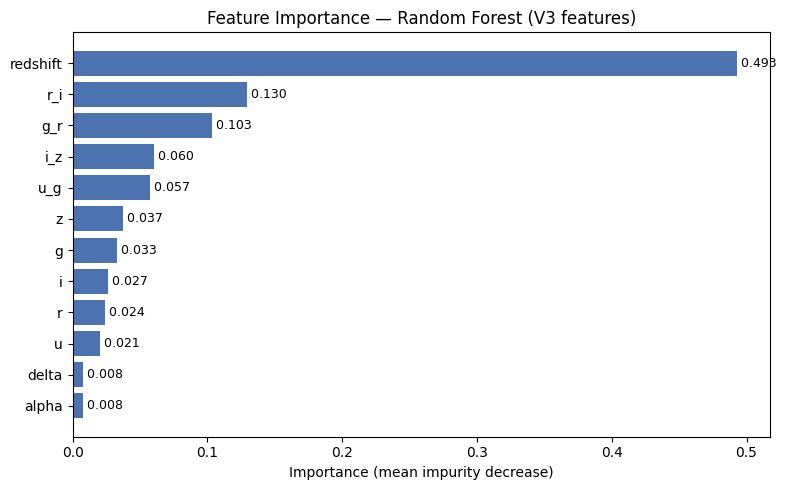

Feature importance ranking:
  redshift   0.4927
  r_i        0.1297
  g_r        0.1035
  i_z        0.0600
  u_g        0.0571
  z          0.0373
  g          0.0331
  i          0.0265
  r          0.0237
  u          0.0206
  delta      0.0080
  alpha      0.0077


In [24]:
# --- Feature importance from a Random Forest on the V3 feature set ---
rf_imp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                n_jobs=-1)
rf_imp.fit(X_train_v3, y_train_v3)

importances = pd.Series(rf_imp.feature_importances_, index=X_v3.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances.values, color='#4C72B0')
ax.set_title("Feature Importance — Random Forest (V3 features)")
ax.set_xlabel("Importance (mean impurity decrease)")
for i, v in enumerate(importances.values):
    ax.text(v, i, f" {v:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for feat, val in importances.sort_values(ascending=False).items():
    print(f"  {feat:10s} {val:.4f}")

## V4 — Class Balancing

The dataset is imbalanced: roughly **59% GALAXY, 19% QSO, 22% STAR**. A model can
reach high *accuracy* simply by favoring the majority class GALAXY, while doing
poorly on the minority class **QSO**.

V4 addresses this with **class weighting**: during training, errors on
under-represented classes are penalized more heavily, in inverse proportion to
class frequency.

- Classical ML models: `class_weight='balanced'`
  (`DecisionTree`, `RandomForest`).
- `XGBoost` / `CatBoost`: per-sample weights computed from class frequencies
  (these libraries do not take a `class_weight` argument directly for
  multi-class the same way).
- `KNN`: has no class-weight option, so it is left unweighted (a documented
  limitation).
- Deep models: a `class_weight` dictionary is passed to `model.fit`.

**Expectation:** overall accuracy may stay almost flat or even dip slightly,
but **macro-F1 should rise**, driven by a clear improvement in **QSO recall**.
This is the key point — V4 trades a little majority-class accuracy for much
fairer treatment of the minority class.

To make this visible, V4 also prints a **per-class report** (precision / recall /
F1 for STAR, GALAXY, QSO) for selected models.

In [25]:
# ============================================================
# V4 — CLASS BALANCING
# Same data/features/split as V3 (cleaned + color indices,
# stratified split, leakage-free scaling).
# Change: class weighting is now applied.
# ============================================================
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# Reuse V3 split exactly
X_train_v4, X_test_v4 = X_train_v3, X_test_v3
y_train_v4, y_test_v4 = y_train_v3, y_test_v3
X_train_scaled_v4, X_test_scaled_v4 = X_train_scaled_v3, X_test_scaled_v3

# Class weights (for DL dict + boosting sample weights)
classes_arr = np.unique(y_train_v4)
cw = compute_class_weight("balanced", classes=classes_arr, y=y_train_v4)
class_weight_dict = dict(zip(classes_arr, cw))
print("Class weights:", {le.classes_[k]: round(v, 3)
                          for k, v in class_weight_dict.items()})

# Per-sample weights for XGBoost / CatBoost
sample_w_train = compute_sample_weight("balanced", y=y_train_v4)

Class weights: {'GALAXY': np.float64(0.561), 'QSO': np.float64(1.758), 'STAR': np.float64(1.544)}


### V4 — Weighted Training & Per-Class Inspection

Each model family receives class balancing in the way its API supports:

- `DecisionTree`, `RandomForest` → `class_weight='balanced'`
- `XGBoost`, `CatBoost` → per-sample weights (`sample_weight`)
- `KNN` → no weighting option; kept as in V3 (documented limitation)
- `MLP`, `CNN`, `LSTM` → `class_weight` dictionary passed to `fit`

After training, a **per-class classification report** is printed so the change
in **QSO recall** — the main goal of this stage — is directly visible.

In [26]:
# ============================================================
# V4 — Classical ML + Boosting with class balancing
# ============================================================
print("=== V4 — Classical ML (weighted, Pipeline + Stratified CV) ===")

def run_weighted_classical_v4(name, estimator, notes, use_sample_weight=False):
    """Pipeline fit + stratified CV, with class balancing."""
    pipe = Pipeline([("scaler", StandardScaler()), ("model", estimator)])
    t0 = time.time()

    if use_sample_weight:
        # boosting: pass sample weights to the 'model' step in CV and final fit
        fit_params = {"model__sample_weight": sample_w_train}
        cv = cross_validate(pipe, X_train_v4, y_train_v4, cv=skf,
                            scoring="f1_macro", n_jobs=-1, params=fit_params)
        pipe.fit(X_train_v4, y_train_v4, model__sample_weight=sample_w_train)
    else:
        # class_weight is set on the estimator itself -> CV handles it
        cv = cross_validate(pipe, X_train_v4, y_train_v4, cv=skf,
                            scoring="f1_macro", n_jobs=-1)
        pipe.fit(X_train_v4, y_train_v4)

    cv_mean, cv_std = cv["test_score"].mean(), cv["test_score"].std()
    pred = pipe.predict(X_test_v4)
    record("V4", name, y_test_v4, pred, time.time() - t0,
           cv_f1macro=cv_mean, notes=notes)
    print(f"      CV macro-F1: {cv_mean:.4f} +/- {cv_std:.4f}")
    return pred

pred_dt = run_weighted_classical_v4("DecisionTree",
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "class_weight=balanced")

pred_rf = run_weighted_classical_v4("RandomForest",
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                           n_jobs=-1, class_weight="balanced"),
    "class_weight=balanced")

# KNN — no weighting option, kept as in V3
pred_knn = run_weighted_classical_v4("KNN",
    KNeighborsClassifier(n_neighbors=5),
    "no class-weight option (unchanged)")

pred_cat = run_weighted_classical_v4("CatBoost",
    CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0),
    "sample_weight=balanced", use_sample_weight=True)

pred_xgb = run_weighted_classical_v4("XGBoost",
    XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                  eval_metric="mlogloss", n_jobs=-1),
    "sample_weight=balanced", use_sample_weight=True)

=== V4 — Classical ML (weighted, Pipeline + Stratified CV) ===
  [V4] DecisionTree     | acc=0.9675 | f1_macro=0.9625 | f1_w=0.9675
      CV macro-F1: 0.9606 +/- 0.0009
  [V4] RandomForest     | acc=0.9798 | f1_macro=0.9765 | f1_w=0.9797
      CV macro-F1: 0.9748 +/- 0.0010
  [V4] KNN              | acc=0.9444 | f1_macro=0.9381 | f1_w=0.9443
      CV macro-F1: 0.9368 +/- 0.0020
  [V4] CatBoost         | acc=0.9744 | f1_macro=0.9709 | f1_w=0.9744
      CV macro-F1: 0.9714 +/- 0.0019
  [V4] XGBoost          | acc=0.9783 | f1_macro=0.9751 | f1_w=0.9783
      CV macro-F1: 0.9736 +/- 0.0013


In [27]:
# ============================================================
# V4 — Deep Learning (stratified validation + class_weight)
# ============================================================
print("=== V4 — Deep Learning (stratified validation, weighted) ===")
tf.random.set_seed(RANDOM_STATE)

t0 = time.time()
pred_mlp = fit_dl_stratified(make_mlp, X_train_scaled_v4, y_train_v4,
                             X_test_scaled_v4, sequence=False,
                             class_weight=class_weight_dict)
record("V4", "MLP", y_test_v4, pred_mlp, time.time() - t0,
       notes="class_weight dict, stratified val")

t0 = time.time()
pred_cnn = fit_dl_stratified(make_cnn, X_train_scaled_v4, y_train_v4,
                             X_test_scaled_v4, sequence=True,
                             class_weight=class_weight_dict)
record("V4", "CNN_1D", y_test_v4, pred_cnn, time.time() - t0,
       notes="class_weight dict, stratified val")

t0 = time.time()
pred_lstm = fit_dl_stratified(make_lstm, X_train_scaled_v4, y_train_v4,
                              X_test_scaled_v4, sequence=True,
                              class_weight=class_weight_dict)
record("V4", "LSTM", y_test_v4, pred_lstm, time.time() - t0,
       notes="class_weight dict, stratified val")

=== V4 — Deep Learning (stratified validation, weighted) ===
  [V4] MLP              | acc=0.9676 | f1_macro=0.9636 | f1_w=0.9677
  [V4] CNN_1D           | acc=0.9520 | f1_macro=0.9456 | f1_w=0.9522
  [V4] LSTM             | acc=0.9624 | f1_macro=0.9579 | f1_w=0.9625


{'version': 'V4',
 'model': 'LSTM',
 'accuracy': 0.96235,
 'f1_macro': 0.9578713636727841,
 'f1_weighted': 0.962463210589218,
 'cv_f1macro': nan,
 'train_time_s': 279.723450422287,
 'notes': 'class_weight dict, stratified val'}

In [28]:
# V4 summary
v4_df = pd.DataFrame([r for r in all_results if r["version"] == "V4"])
print("=== V4 — Summary (all 8 models) ===")
print(v4_df[["model", "accuracy", "f1_macro", "f1_weighted",
             "cv_f1macro", "train_time_s"]].round(4).to_string(index=False))

# Delta vs V3
v3_df = pd.DataFrame([r for r in all_results if r["version"] == "V3"])
cmp = v3_df[["model", "f1_macro"]].merge(
    v4_df[["model", "f1_macro"]], on="model", suffixes=("_V3", "_V4"))
cmp["delta"] = (cmp["f1_macro_V4"] - cmp["f1_macro_V3"]).round(4)
print("\n=== F1-macro change: V3 -> V4 ===")
print(cmp.round(4).to_string(index=False))

# --- QSO recall: V3 vs V4, the key effect of class balancing ---
qso_idx = list(le.classes_).index("QSO")

def qso_recall(y_true, y_pred):
    """Recall for the QSO class only."""
    mask = (y_true == qso_idx)
    return (y_pred[mask] == qso_idx).mean()

print("\n=== QSO recall: V3 -> V4 ===")
v4_preds = {"DecisionTree": pred_dt, "RandomForest": pred_rf, "KNN": pred_knn,
            "CatBoost": pred_cat, "XGBoost": pred_xgb,
            "MLP": pred_mlp, "CNN_1D": pred_cnn, "LSTM": pred_lstm}
for mname, mpred in v4_preds.items():
    r = qso_recall(y_test_v4, mpred)
    print(f"  {mname:14s} QSO recall (V4): {r:.4f}")

# Full per-class report for one representative model (RandomForest)
print("\n--- Per-class report — RandomForest (V4) ---")
print(classification_report(y_test_v4, pred_rf, target_names=le.classes_, digits=4))

=== V4 — Summary (all 8 models) ===
       model  accuracy  f1_macro  f1_weighted  cv_f1macro  train_time_s
DecisionTree    0.9675    0.9625       0.9675      0.9606       20.3377
RandomForest    0.9798    0.9765       0.9797      0.9748      228.4986
         KNN    0.9444    0.9381       0.9443      0.9368       27.5120
    CatBoost    0.9744    0.9709       0.9744      0.9714       54.7417
     XGBoost    0.9783    0.9751       0.9783      0.9736       35.8008
         MLP    0.9676    0.9636       0.9677         NaN       47.8638
      CNN_1D    0.9520    0.9456       0.9522         NaN      111.0878
        LSTM    0.9624    0.9579       0.9625         NaN      279.7235

=== F1-macro change: V3 -> V4 ===
       model  f1_macro_V3  f1_macro_V4   delta
DecisionTree       0.9632       0.9625 -0.0007
RandomForest       0.9765       0.9765 -0.0000
         KNN       0.9381       0.9381  0.0000
    CatBoost       0.9735       0.9709 -0.0025
     XGBoost       0.9738       0.9751  0.0013

### Confusion Matrix — Best Model

The confusion matrix shows *which* classes the model confuses, not just the
overall score. It is shown for the best-performing model after V4 (Random
Forest), using its predictions on the hold-out test set.

Reading it confirms the earlier EDA: `STAR` should be almost never confused
(redshift ≈ 0 and the tight stellar locus make it easy), while the few remaining
errors are expected to be `GALAXY` <-> `QSO`, the two classes whose redshift and
color ranges partially overlap.

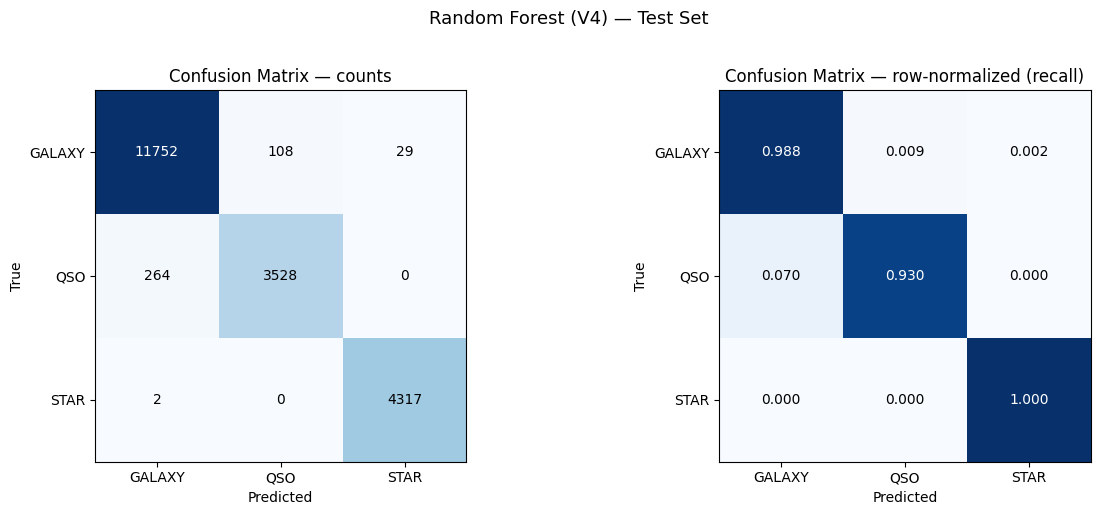

Main off-diagonal errors (true -> predicted):
  GALAXY  -> QSO    :   108  (0.91% of true GALAXY)
  GALAXY  -> STAR   :    29  (0.24% of true GALAXY)
  QSO     -> GALAXY :   264  (6.96% of true QSO)
  STAR    -> GALAXY :     2  (0.05% of true STAR)


In [29]:
# --- Confusion matrix for the best V4 model (Random Forest) ---
cm = confusion_matrix(y_test_v4, pred_rf)
cm_norm = cm / cm.sum(axis=1, keepdims=True)   # row-normalized (recall view)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, fmt in [
    (axes[0], cm, "Confusion Matrix — counts", "d"),
    (axes[1], cm_norm, "Confusion Matrix — row-normalized (recall)", ".3f"),
]:
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(len(le.classes_)))
    ax.set_yticks(range(len(le.classes_)))
    ax.set_xticklabels(le.classes_)
    ax.set_yticklabels(le.classes_)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = mat.max() / 2
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = format(mat[i, j], fmt)
            ax.text(j, i, val, ha='center', va='center',
                    color='white' if mat[i, j] > thresh else 'black')

plt.suptitle("Random Forest (V4) — Test Set", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# textual summary of the main confusion
print("Main off-diagonal errors (true -> predicted):")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i, j] > 0:
            print(f"  {le.classes_[i]:7s} -> {le.classes_[j]:7s}: "
                  f"{cm[i, j]:5d}  ({cm_norm[i, j]*100:.2f}% of true {le.classes_[i]})")

## V5 — Feature Selection (dropping non-physical coordinates)

The final stage applies a decision that came directly from the **feature
importance** analysis. There, `alpha` (right ascension) and `delta` (declination)
ranked **last**, with about 0.008 importance each — together only ~1.6% of the
total.

These two columns are **sky coordinates**: they describe *where* an object is in
the sky, not *what* it physically is. Keeping them carries two small risks:

- they add no real astrophysical signal, and
- coordinates can leak survey-specific patterns (the SDSS scan footprint).

V5 therefore drops `alpha` and `delta`, keeping only physically meaningful
features. Everything else is identical to V4.

**Expectation:** macro-F1 should stay essentially flat. A flat result here is a
*success* — it shows the model was simplified (fewer features, cleaner
methodology) **without losing performance**, which is exactly what good feature
selection should achieve.

In [30]:
# ============================================================
# V5 — FEATURE SELECTION
# Same as V4 (cleaned + color indices, stratified, class-weighted),
# but drop the non-physical coordinate columns alpha & delta.
# ============================================================

drop_coords = ['alpha', 'delta']
X_v5 = X_v2.drop(columns=drop_coords)   # X_v2 = cleaned + color indices
y_v5_enc = y_v2_enc.copy()

print("V5 feature count:", X_v5.shape[1], "(V4 had", X_v2.shape[1], ")")
print("V5 features:", list(X_v5.columns))

# Stratified split (same scheme as V3/V4)
X_train_v5, X_test_v5, y_train_v5, y_test_v5 = train_test_split(
    X_v5, y_v5_enc, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y_v5_enc
)
print("Train:", X_train_v5.shape, "| Test:", X_test_v5.shape)

# Class weights & sample weights for the V5 training set
classes_arr = np.unique(y_train_v5)
cw = compute_class_weight("balanced", classes=classes_arr, y=y_train_v5)
class_weight_dict_v5 = dict(zip(classes_arr, cw))
sample_w_train_v5 = compute_sample_weight("balanced", y=y_train_v5)
print("Class weights:", {le.classes_[k]: round(v, 3)
                         for k, v in class_weight_dict_v5.items()})

# Leakage-free scaling for the deep models (fit on train only)
scaler_v5 = StandardScaler()
X_train_scaled_v5 = scaler_v5.fit_transform(X_train_v5)
X_test_scaled_v5  = scaler_v5.transform(X_test_v5)

V5 feature count: 10 (V4 had 12 )
V5 features: ['u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']
Train: (79999, 10) | Test: (20000, 10)
Class weights: {'GALAXY': np.float64(0.561), 'QSO': np.float64(1.758), 'STAR': np.float64(1.544)}


### V5 — Model Training (10 physical features)

All eight models are trained exactly as in V4 — class-weighted, with a Pipeline
for leakage-free scaling and stratified cross-validation — but on the reduced
10-feature set without `alpha` and `delta`.

In [31]:
# ============================================================
# V5 — Classical ML + Boosting (weighted, reduced feature set)
# ============================================================
print("=== V5 — Classical ML (weighted, Pipeline + Stratified CV) ===")

def run_weighted_classical_v5(name, estimator, notes, use_sample_weight=False):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", estimator)])
    t0 = time.time()

    if use_sample_weight:
        fit_params = {"model__sample_weight": sample_w_train_v5}
        cv = cross_validate(pipe, X_train_v5, y_train_v5, cv=skf,
                            scoring="f1_macro", n_jobs=-1, params=fit_params)
        pipe.fit(X_train_v5, y_train_v5, model__sample_weight=sample_w_train_v5)
    else:
        cv = cross_validate(pipe, X_train_v5, y_train_v5, cv=skf,
                            scoring="f1_macro", n_jobs=-1)
        pipe.fit(X_train_v5, y_train_v5)

    cv_mean, cv_std = cv["test_score"].mean(), cv["test_score"].std()
    pred = pipe.predict(X_test_v5)
    record("V5", name, y_test_v5, pred, time.time() - t0,
           cv_f1macro=cv_mean, notes=notes)
    print(f"      CV macro-F1: {cv_mean:.4f} +/- {cv_std:.4f}")
    return pred

pred_dt  = run_weighted_classical_v5("DecisionTree",
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "feature selection (no alpha/delta)")

pred_rf  = run_weighted_classical_v5("RandomForest",
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                           n_jobs=-1, class_weight="balanced"),
    "feature selection (no alpha/delta)")

pred_knn = run_weighted_classical_v5("KNN",
    KNeighborsClassifier(n_neighbors=5),
    "feature selection (no alpha/delta)")

pred_cat = run_weighted_classical_v5("CatBoost",
    CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0),
    "feature selection (no alpha/delta)", use_sample_weight=True)

pred_xgb = run_weighted_classical_v5("XGBoost",
    XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                  eval_metric="mlogloss", n_jobs=-1),
    "feature selection (no alpha/delta)", use_sample_weight=True)

=== V5 — Classical ML (weighted, Pipeline + Stratified CV) ===
  [V5] DecisionTree     | acc=0.9664 | f1_macro=0.9613 | f1_w=0.9664
      CV macro-F1: 0.9607 +/- 0.0013
  [V5] RandomForest     | acc=0.9802 | f1_macro=0.9769 | f1_w=0.9801
      CV macro-F1: 0.9754 +/- 0.0015
  [V5] KNN              | acc=0.9558 | f1_macro=0.9507 | f1_w=0.9558
      CV macro-F1: 0.9500 +/- 0.0018
  [V5] CatBoost         | acc=0.9735 | f1_macro=0.9699 | f1_w=0.9735
      CV macro-F1: 0.9713 +/- 0.0019
  [V5] XGBoost          | acc=0.9784 | f1_macro=0.9751 | f1_w=0.9783
      CV macro-F1: 0.9727 +/- 0.0011


In [32]:
# ============================================================
# V5 — Deep Learning (stratified validation + class_weight)
# ============================================================
print("=== V5 — Deep Learning (stratified validation, weighted) ===")
tf.random.set_seed(RANDOM_STATE)

t0 = time.time()
pred_mlp = fit_dl_stratified(make_mlp, X_train_scaled_v5, y_train_v5,
                             X_test_scaled_v5, sequence=False,
                             class_weight=class_weight_dict_v5)
record("V5", "MLP", y_test_v5, pred_mlp, time.time() - t0,
       notes="feature selection, stratified val")

t0 = time.time()
pred_cnn = fit_dl_stratified(make_cnn, X_train_scaled_v5, y_train_v5,
                             X_test_scaled_v5, sequence=True,
                             class_weight=class_weight_dict_v5)
record("V5", "CNN_1D", y_test_v5, pred_cnn, time.time() - t0,
       notes="feature selection, stratified val")

t0 = time.time()
pred_lstm = fit_dl_stratified(make_lstm, X_train_scaled_v5, y_train_v5,
                              X_test_scaled_v5, sequence=True,
                              class_weight=class_weight_dict_v5)
record("V5", "LSTM", y_test_v5, pred_lstm, time.time() - t0,
       notes="feature selection, stratified val")

=== V5 — Deep Learning (stratified validation, weighted) ===
  [V5] MLP              | acc=0.9689 | f1_macro=0.9650 | f1_w=0.9690
  [V5] CNN_1D           | acc=0.9565 | f1_macro=0.9506 | f1_w=0.9566
  [V5] LSTM             | acc=0.9540 | f1_macro=0.9490 | f1_w=0.9542


{'version': 'V5',
 'model': 'LSTM',
 'accuracy': 0.954,
 'f1_macro': 0.9490032709732249,
 'f1_weighted': 0.9542027553318807,
 'cv_f1macro': nan,
 'train_time_s': 241.63518691062927,
 'notes': 'feature selection, stratified val'}

In [33]:
# V5 summary + comparison vs V4
v5_df = pd.DataFrame([r for r in all_results if r["version"] == "V5"])
print("=== V5 — Summary (all 8 models) ===")
print(v5_df[["model", "accuracy", "f1_macro", "f1_weighted",
             "cv_f1macro", "train_time_s"]].round(4).to_string(index=False))

# Delta vs V4
v4_df = pd.DataFrame([r for r in all_results if r["version"] == "V4"])
cmp = v4_df[["model", "f1_macro"]].merge(
    v5_df[["model", "f1_macro"]], on="model", suffixes=("_V4", "_V5"))
cmp["delta"] = (cmp["f1_macro_V5"] - cmp["f1_macro_V4"]).round(4)
print("\n=== F1-macro change: V4 -> V5 ===")
print(cmp.round(4).to_string(index=False))

=== V5 — Summary (all 8 models) ===
       model  accuracy  f1_macro  f1_weighted  cv_f1macro  train_time_s
DecisionTree    0.9664    0.9613       0.9664      0.9607       16.8960
RandomForest    0.9802    0.9769       0.9801      0.9754      217.0817
         KNN    0.9558    0.9507       0.9558      0.9500        9.9373
    CatBoost    0.9735    0.9699       0.9735      0.9713       48.2531
     XGBoost    0.9784    0.9751       0.9783      0.9727       31.3920
         MLP    0.9689    0.9650       0.9690         NaN       61.0321
      CNN_1D    0.9564    0.9506       0.9566         NaN      129.3591
        LSTM    0.9540    0.9490       0.9542         NaN      241.6352

=== F1-macro change: V4 -> V5 ===
       model  f1_macro_V4  f1_macro_V5   delta
DecisionTree       0.9625       0.9613 -0.0012
RandomForest       0.9765       0.9769  0.0004
         KNN       0.9381       0.9507  0.0127
    CatBoost       0.9709       0.9699 -0.0010
     XGBoost       0.9751       0.9751  0.0000

# Final Results — Ablation Summary

This section brings the whole study together. Every model was evaluated at six
stages (V0 to V5), each stage adding one improvement:

| Stage | Improvement added |
|-------|-------------------|
| V0 | Naive baseline (no preprocessing) |
| V1 | Data cleaning (drop sentinels & ID columns) |
| V2 | Feature engineering (color indices) |
| V3 | Leakage fix (Pipeline) + stratified split & CV |
| V4 | Class balancing (class weights) |
| V5 | Feature selection (drop non-physical coordinates) |

The plots and tables below show how each step affected performance, per model
and overall.

In [34]:
# --- Master results table: all versions, all models ---
results_df = pd.DataFrame(all_results)
version_order = ["V0", "V1", "V2", "V3", "V4", "V5"]
results_df["version"] = pd.Categorical(results_df["version"],
                                       categories=version_order, ordered=True)

# Pivot: rows = model, columns = version, values = macro-F1
f1_pivot = results_df.pivot_table(index="model", columns="version",
                                  values="f1_macro", observed=True)
print("=== Macro-F1 across all stages ===")
print(f1_pivot.round(4).to_string())

# Total change V0 -> V5 per model
f1_pivot["V0_to_V5"] = (f1_pivot["V5"] - f1_pivot["V0"]).round(4)
print("\n=== Total macro-F1 change (V0 -> V5) ===")
print(f1_pivot["V0_to_V5"].sort_values(ascending=False).to_string())

=== Macro-F1 across all stages ===
version           V0      V1      V2      V3      V4      V5
model                                                       
CNN_1D        0.4825  0.9229  0.7684  0.9542  0.9456  0.9506
CatBoost      0.9740  0.9720  0.9739  0.9735  0.9709  0.9699
DecisionTree  0.9584  0.9592  0.9608  0.9632  0.9625  0.9613
KNN           0.8839  0.9319  0.9378  0.9381  0.9381  0.9507
LSTM          0.5210  0.9242  0.8353  0.9637  0.9579  0.9490
MLP           0.9628  0.9654  0.9651  0.9699  0.9636  0.9650
RandomForest  0.9751  0.9734  0.9741  0.9765  0.9765  0.9769
XGBoost       0.9735  0.9710  0.9719  0.9738  0.9751  0.9751

=== Total macro-F1 change (V0 -> V5) ===
model
CNN_1D          0.4681
LSTM            0.4280
KNN             0.0668
DecisionTree    0.0028
MLP             0.0022
RandomForest    0.0018
XGBoost         0.0016
CatBoost       -0.0041


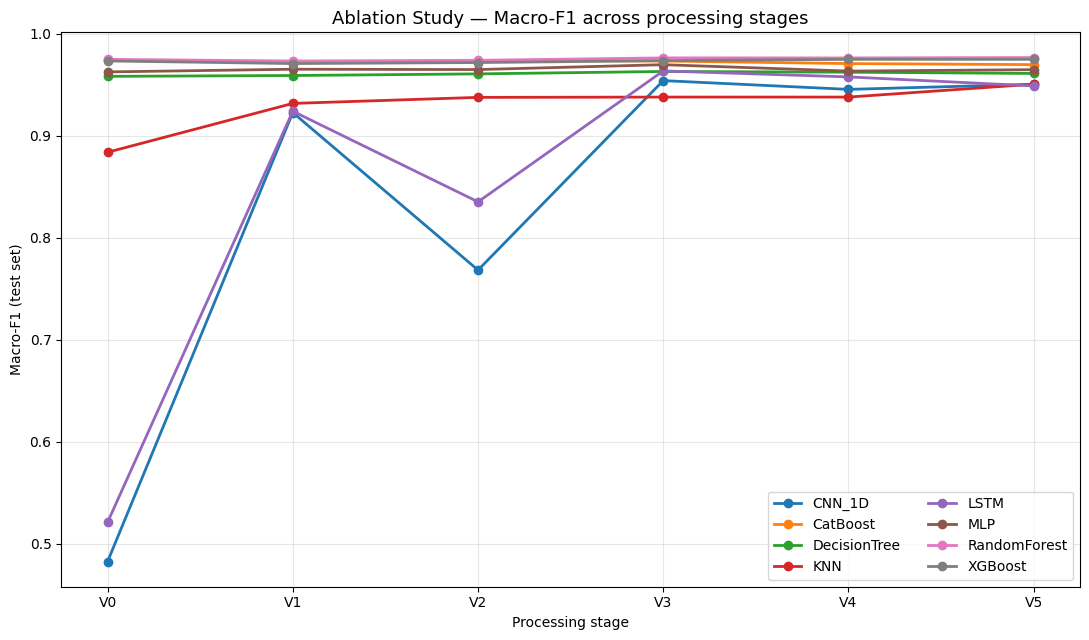

In [35]:
# --- Ablation curve: macro-F1 vs stage, one line per model ---
fig, ax = plt.subplots(figsize=(11, 6.5))

cmap = plt.cm.tab10
for idx, model in enumerate(f1_pivot.index):
    ax.plot(version_order,
            [f1_pivot.loc[model, v] for v in version_order],
            marker="o", linewidth=2, label=model, color=cmap(idx))

ax.set_title("Ablation Study — Macro-F1 across processing stages", fontsize=13)
ax.set_xlabel("Processing stage")
ax.set_ylabel("Macro-F1 (test set)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

# Discussion: The Role of Redshift

The feature importance analysis showed that **`redshift` alone accounts for
about 49% of the total importance** — more than all other features combined.
This raises an important question that goes beyond the ablation chain.

In the SDSS dataset, the class label (`STAR` / `GALAXY` / `QSO`) is determined
**spectroscopically**, and `redshift` is *also* measured from the same spectrum.
So redshift is not an independent photometric measurement — it is derived from
the very observation that produced the label. Using it as a feature is therefore
a mild form of **label leakage**: the model is partly given information that is
tied to how the label itself was created.

This is different from the `alpha`/`delta` removal in V5 (which was an *empirical*
decision based on low importance). Dropping redshift is a *conceptual* decision
based on how the data was generated. To make the effect concrete, the experiment
below removes redshift entirely and re-runs all eight models on a **purely
photometric** feature set (magnitudes + color indices only).

**Expectation:** scores should drop noticeably — this quantifies how much of the
performance was carried by a single, possibly leaky, feature, and shows how well
the models do under a realistic *photometry-only* scenario.

In [36]:
# ============================================================
# Redshift ablation — purely photometric feature set
# Start from the V5 feature set and additionally drop redshift.
# Everything else identical to V5 (cleaned, color indices, stratified,
# class-weighted, leakage-free scaling, stratified DL validation).
# ============================================================
X_noz = X_v5.drop(columns=["redshift"])
y_noz_enc = y_v5_enc.copy()

print("Photometry-only feature count:", X_noz.shape[1])
print("Features:", list(X_noz.columns))

# Stratified split (same scheme)
X_train_nz, X_test_nz, y_train_nz, y_test_nz = train_test_split(
    X_noz, y_noz_enc, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y_noz_enc
)

# Class / sample weights for this training set
classes_arr = np.unique(y_train_nz)
cw_nz = compute_class_weight("balanced", classes=classes_arr, y=y_train_nz)
class_weight_dict_nz = dict(zip(classes_arr, cw_nz))
sample_w_train_nz = compute_sample_weight("balanced", y=y_train_nz)

# Leakage-free scaling for the deep models
scaler_nz = StandardScaler()
X_train_scaled_nz = scaler_nz.fit_transform(X_train_nz)
X_test_scaled_nz  = scaler_nz.transform(X_test_nz)

print("Train:", X_train_nz.shape, "| Test:", X_test_nz.shape)

Photometry-only feature count: 9
Features: ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z']
Train: (79999, 9) | Test: (20000, 9)


In [37]:
# ============================================================
# Redshift ablation — Classical ML + Boosting (weighted)
# Results recorded under version label "NoZ" (no redshift).
# ============================================================
print("=== Photometry-only (no redshift) — Classical ML ===")

def run_noz_classical(name, estimator, notes, use_sample_weight=False):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", estimator)])
    t0 = time.time()
    if use_sample_weight:
        fit_params = {"model__sample_weight": sample_w_train_nz}
        cv = cross_validate(pipe, X_train_nz, y_train_nz, cv=skf,
                            scoring="f1_macro", n_jobs=-1, params=fit_params)
        pipe.fit(X_train_nz, y_train_nz, model__sample_weight=sample_w_train_nz)
    else:
        cv = cross_validate(pipe, X_train_nz, y_train_nz, cv=skf,
                            scoring="f1_macro", n_jobs=-1)
        pipe.fit(X_train_nz, y_train_nz)
    cv_mean = cv["test_score"].mean()
    pred = pipe.predict(X_test_nz)
    record("NoZ", name, y_test_nz, pred, time.time() - t0,
           cv_f1macro=cv_mean, notes=notes)

run_noz_classical("DecisionTree",
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "no redshift")
run_noz_classical("RandomForest",
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                           n_jobs=-1, class_weight="balanced"),
    "no redshift")
run_noz_classical("KNN",
    KNeighborsClassifier(n_neighbors=5), "no redshift")
run_noz_classical("CatBoost",
    CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0),
    "no redshift", use_sample_weight=True)
run_noz_classical("XGBoost",
    XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                  eval_metric="mlogloss", n_jobs=-1),
    "no redshift", use_sample_weight=True)

=== Photometry-only (no redshift) — Classical ML ===
  [NoZ] DecisionTree     | acc=0.8335 | f1_macro=0.7921 | f1_w=0.8335
  [NoZ] RandomForest     | acc=0.8855 | f1_macro=0.8525 | f1_w=0.8841
  [NoZ] KNN              | acc=0.8761 | f1_macro=0.8415 | f1_w=0.8746
  [NoZ] CatBoost         | acc=0.8700 | f1_macro=0.8402 | f1_w=0.8716
  [NoZ] XGBoost          | acc=0.8801 | f1_macro=0.8508 | f1_w=0.8808


In [38]:
# ============================================================
# Redshift ablation — Deep Learning (stratified validation, weighted)
# ============================================================
print("=== Photometry-only (no redshift) — Deep Learning ===")
tf.random.set_seed(RANDOM_STATE)

t0 = time.time()
pred = fit_dl_stratified(make_mlp, X_train_scaled_nz, y_train_nz,
                         X_test_scaled_nz, sequence=False,
                         class_weight=class_weight_dict_nz)
record("NoZ", "MLP", y_test_nz, pred, time.time() - t0, notes="no redshift")

t0 = time.time()
pred = fit_dl_stratified(make_cnn, X_train_scaled_nz, y_train_nz,
                         X_test_scaled_nz, sequence=True,
                         class_weight=class_weight_dict_nz)
record("NoZ", "CNN_1D", y_test_nz, pred, time.time() - t0, notes="no redshift")

t0 = time.time()
pred = fit_dl_stratified(make_lstm, X_train_scaled_nz, y_train_nz,
                         X_test_scaled_nz, sequence=True,
                         class_weight=class_weight_dict_nz)
record("NoZ", "LSTM", y_test_nz, pred, time.time() - t0, notes="no redshift")

=== Photometry-only (no redshift) — Deep Learning ===
  [NoZ] MLP              | acc=0.8743 | f1_macro=0.8459 | f1_w=0.8758
  [NoZ] CNN_1D           | acc=0.8700 | f1_macro=0.8389 | f1_w=0.8708
  [NoZ] LSTM             | acc=0.8582 | f1_macro=0.8276 | f1_w=0.8605


{'version': 'NoZ',
 'model': 'LSTM',
 'accuracy': 0.8582,
 'f1_macro': 0.8276207441291336,
 'f1_weighted': 0.8604751589484003,
 'cv_f1macro': nan,
 'train_time_s': 150.82371950149536,
 'notes': 'no redshift'}

=== Effect of removing redshift (V5 -> photometry-only) ===
       model  f1_macro_V5  f1_macro_NoZ   drop
DecisionTree       0.9613        0.7921 0.1692
    CatBoost       0.9699        0.8402 0.1297
RandomForest       0.9769        0.8525 0.1243
     XGBoost       0.9751        0.8508 0.1243
        LSTM       0.9490        0.8276 0.1214
         MLP       0.9650        0.8459 0.1191
      CNN_1D       0.9506        0.8389 0.1117
         KNN       0.9507        0.8415 0.1092

Mean macro-F1 with redshift   (V5):  0.9623
Mean macro-F1 without redshift (NoZ): 0.8362
Mean drop across models:              0.1261


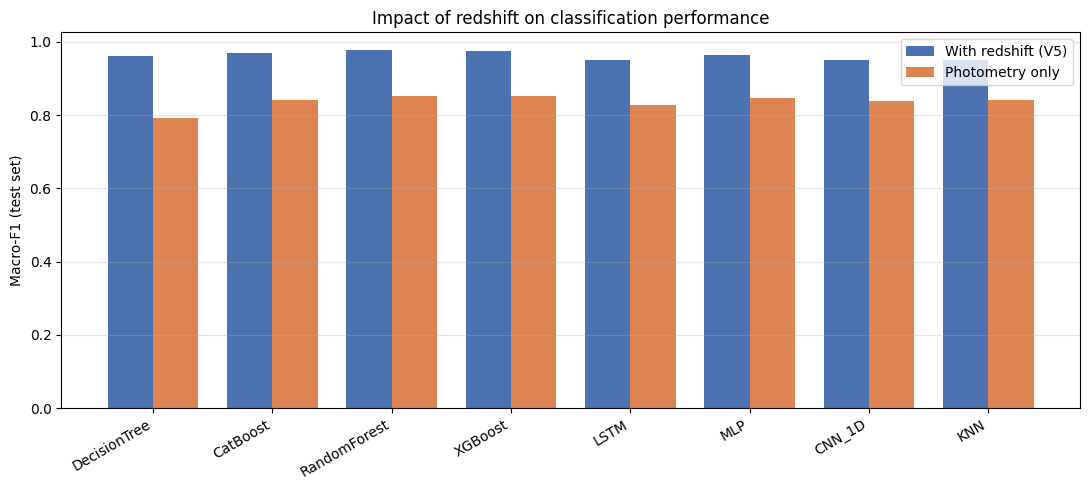

In [39]:
# Compare V5 (with redshift) vs NoZ (without redshift)
v5_df  = pd.DataFrame([r for r in all_results if r["version"] == "V5"])
noz_df = pd.DataFrame([r for r in all_results if r["version"] == "NoZ"])

cmp = v5_df[["model", "f1_macro"]].merge(
    noz_df[["model", "f1_macro"]], on="model", suffixes=("_V5", "_NoZ"))
cmp["drop"] = (cmp["f1_macro_V5"] - cmp["f1_macro_NoZ"]).round(4)
cmp = cmp.sort_values("drop", ascending=False)
print("=== Effect of removing redshift (V5 -> photometry-only) ===")
print(cmp.round(4).to_string(index=False))

print(f"\nMean macro-F1 with redshift   (V5):  {v5_df['f1_macro'].mean():.4f}")
print(f"Mean macro-F1 without redshift (NoZ): {noz_df['f1_macro'].mean():.4f}")
print(f"Mean drop across models:              "
      f"{(v5_df['f1_macro'].mean() - noz_df['f1_macro'].mean()):.4f}")

# bar chart: side-by-side F1 with vs without redshift
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cmp)); w = 0.38
ax.bar(x - w/2, cmp["f1_macro_V5"],  w, label="With redshift (V5)", color="#4C72B0")
ax.bar(x + w/2, cmp["f1_macro_NoZ"], w, label="Photometry only",    color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(cmp["model"], rotation=30, ha="right")
ax.set_ylabel("Macro-F1 (test set)")
ax.set_title("Impact of redshift on classification performance")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Bonus: Hyperparameter Tuning

Throughout V0–V5, every model used **default hyperparameters** — the ablation
study deliberately isolated the effect of *data processing*, not model tuning.

This section asks a separate question: with the data pipeline fixed at its best
(V5), how much extra performance can hyperparameter tuning add?
`RandomizedSearchCV` is run on the two strongest models from the ablation study
(**Random Forest** and **XGBoost**), using the V5 feature set and stratified CV.

**Expectation:** only a small gain. The ablation study already pushed these
models close to their ceiling on this dataset, so tuning should refine the last
fraction of a percent rather than produce large jumps. A small gain here is
itself a finding — it shows that *data quality*, not hyperparameter search, was
the dominant factor in this project.

In [48]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.model_selection import train_test_split as tts

tuning_results = []
f1_pivot_v5 = pd.DataFrame([r for r in all_results if r["version"] == "V5"]) \
                .set_index("model")["f1_macro"]

# %20'ye indirdik (30 yerine) — RF için yeterli
X_tune, _, y_tune, _, sw_tune, _ = tts(
    X_train_v5, y_train_v5, sample_w_train_v5,
    train_size=0.20, stratify=y_train_v5, random_state=RANDOM_STATE
)
print(f"Tuning subset: {X_tune.shape}  (full train: {X_train_v5.shape})")

def tune_model(name, estimator, param_dist, use_sample_weight=False):
    print(f"\n--- Tuning {name} ---")
    search = HalvingRandomSearchCV(
        estimator, param_distributions=param_dist,
        scoring="f1_macro", cv=skf,
        factor=3, n_candidates="exhaust",
        min_resources="smallest",
        n_jobs=-1, random_state=RANDOM_STATE, verbose=0
    )
    t0 = time.time()
    if use_sample_weight:
        search.fit(X_tune, y_tune, sample_weight=sw_tune)
    else:
        search.fit(X_tune, y_tune)
    elapsed = time.time() - t0

    best = search.best_estimator_
    pred      = best.predict(X_test_v5)
    test_f1   = f1_score(y_test_v5, pred, average="macro")
    default_f1 = f1_pivot_v5[name]

    print(f"  Best CV macro-F1 : {search.best_score_:.4f}")
    print(f"  Default test F1  : {default_f1:.4f}")
    print(f"  Tuned  test F1   : {test_f1:.4f}  (delta {test_f1-default_f1:+.4f})")
    print(f"  Best params      : {search.best_params_}")
    print(f"  Search time      : {elapsed:.1f}s")

    tuning_results.append({
        "model": name, "default_f1": round(default_f1, 4),
        "tuned_f1": round(test_f1, 4),
        "delta": round(test_f1 - default_f1, 4),
        "best_params": search.best_params_})
    return best

# ── RandomForest — n_estimators daha da kısıldı ─────────────────────────
rf_params = {
    "n_estimators"    : [50, 100, 200],      # 300 çıkarıldı
    "max_depth"       : [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"    : ["sqrt", "log2"]
}
tune_model(
    "RandomForest",
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                           class_weight="balanced"),
    rf_params
)

# ── XGBoost — early_stopping_rounds KALDIRILDI (eval_set olmadan çalışmıyor)
xgb_params = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [3, 5, 7],
    "learning_rate"   : [0.05, 0.1, 0.2],
    "subsample"       : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}
tune_model(
    "XGBoost",
    XGBClassifier(                           # early_stopping_rounds YOK
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    xgb_params,
    use_sample_weight=True
)

Tuning subset: (15999, 10)  (full train: (79999, 10))

--- Tuning RandomForest ---
  Best CV macro-F1 : 0.9612
  Default test F1  : 0.9769
  Tuned  test F1   : 0.9721  (delta -0.0048)
  Best params      : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
  Search time      : 381.5s

--- Tuning XGBoost ---
  Best CV macro-F1 : 0.9645
  Default test F1  : 0.9751
  Tuned  test F1   : 0.9734  (delta -0.0017)
  Best params      : {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  Search time      : 141.6s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [49]:
# Tuning summary: default (V5) vs tuned
tuning_df = pd.DataFrame(tuning_results)
print("=== Hyperparameter Tuning — Default (V5) vs Tuned ===")
print(tuning_df[["model", "default_f1", "tuned_f1", "delta"]].to_string(index=False))
print("\nBest parameters found:")
for r in tuning_results:
    print(f"  {r['model']}: {r['best_params']}")

=== Hyperparameter Tuning — Default (V5) vs Tuned ===
       model  default_f1  tuned_f1   delta
RandomForest      0.9769    0.9721 -0.0048
     XGBoost      0.9751    0.9734 -0.0017

Best parameters found:
  RandomForest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
  XGBoost: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# Statistical Significance: Are the differences real?

Many of the deltas between stages are small (often ±0.002 macro-F1). A natural
question is whether such differences are **statistically meaningful** or just
random fluctuation. Two complementary checks are used.

**1. Cross-validation stability.** The classical models already produced a
5-fold CV macro-F1 *mean ± std*. If two models' scores differ by less than their
CV standard deviation, the difference is within noise.

**2. McNemar's test.** This is the standard test for comparing two classifiers on
the *same* test set. It looks only at the cases where the two models **disagree**
(one right, the other wrong) and tests whether that disagreement is symmetric. A
small p-value (< 0.05) means one model is significantly better than the other on
this test set.

Below, McNemar's test compares the best model against the others on the V5 test
set, to see which performance gaps are real and which are within noise.

In [50]:
# ============================================================
# McNemar's test on the V5 test set
# Compare the best model (highest V5 macro-F1) against each other model.
# Requires per-model predictions on the SAME test set (V5).
# ============================================================
from itertools import combinations
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    !pip -q install statsmodels
    from statsmodels.stats.contingency_tables import mcnemar

# Re-generate V5 predictions for every model on the SAME test set,
# so McNemar can compare them pairwise.
v5_preds = {}

# classical / boosting (Pipeline, weighted as in V5)
def _fit_pred(est, sw=None):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", est)])
    if sw is not None:
        pipe.fit(X_train_v5, y_train_v5, model__sample_weight=sw)
    else:
        pipe.fit(X_train_v5, y_train_v5)
    return pipe.predict(X_test_v5)

v5_preds["DecisionTree"] = _fit_pred(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
v5_preds["RandomForest"] = _fit_pred(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                           n_jobs=-1, class_weight="balanced"))
v5_preds["KNN"] = _fit_pred(KNeighborsClassifier(n_neighbors=5))
v5_preds["CatBoost"] = _fit_pred(
    CatBoostClassifier(iterations=200, random_seed=RANDOM_STATE, verbose=0),
    sw=sample_w_train_v5)
v5_preds["XGBoost"] = _fit_pred(
    XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                  eval_metric="mlogloss", n_jobs=-1), sw=sample_w_train_v5)

# deep models (stratified validation, weighted) — reuse helper
tf.random.set_seed(RANDOM_STATE)
v5_preds["MLP"] = fit_dl_stratified(make_mlp, X_train_scaled_v5, y_train_v5,
                                    X_test_scaled_v5, sequence=False,
                                    class_weight=class_weight_dict_v5)
v5_preds["CNN_1D"] = fit_dl_stratified(make_cnn, X_train_scaled_v5, y_train_v5,
                                       X_test_scaled_v5, sequence=True,
                                       class_weight=class_weight_dict_v5)
v5_preds["LSTM"] = fit_dl_stratified(make_lstm, X_train_scaled_v5, y_train_v5,
                                     X_test_scaled_v5, sequence=True,
                                     class_weight=class_weight_dict_v5)

# pick the best model by test macro-F1
best_model = max(v5_preds, key=lambda m: f1_score(y_test_v5, v5_preds[m],
                                                  average="macro"))
print(f"Best model on V5 test set: {best_model}\n")

print(f"=== McNemar's test: {best_model} vs each other model ===")
print(f"{'Model':14s} {'b (best wrong)':>14s} {'c (other wrong)':>16s} {'p-value':>10s}  significant?")
y_true = y_test_v5
best_correct = (v5_preds[best_model] == y_true)
for m in v5_preds:
    if m == best_model:
        continue
    other_correct = (v5_preds[m] == y_true)
    # contingency: b = best right & other wrong, c = best wrong & other right
    b = int(np.sum(best_correct & ~other_correct))
    c = int(np.sum(~best_correct & other_correct))
    table = [[int(np.sum(best_correct & other_correct)), b],
             [c, int(np.sum(~best_correct & ~other_correct))]]
    res = mcnemar(table, exact=False, correction=True)
    sig = "yes" if res.pvalue < 0.05 else "no (within noise)"
    print(f"{m:14s} {b:>14d} {c:>16d} {res.pvalue:>10.4g}  {sig}")

Best model on V5 test set: RandomForest

=== McNemar's test: RandomForest vs each other model ===
Model          b (best wrong)  c (other wrong)    p-value  significant?
DecisionTree              361               84  4.083e-39  yes
KNN                       548               61  2.441e-86  yes
CatBoost            221507216          2579493          0  yes
XGBoost                   121               84    0.01193  yes
MLP                       325              107  1.621e-25  yes
CNN_1D                    603              101  1.599e-79  yes
LSTM                      586               90   8.19e-81  yes


In [51]:
# CV stability view: macro-F1 mean +/- std for classical models across stages
cv_view = pd.DataFrame([r for r in all_results
                        if not np.isnan(r["cv_f1macro"])])
cv_tbl = cv_view.pivot_table(index="model", columns="version",
                             values="cv_f1macro", observed=True)
print("=== Cross-validated macro-F1 (mean) by stage — classical models ===")
print(cv_tbl.round(4).to_string())
print("\nNote: deltas smaller than a model's CV std should be read as 'within noise'.")

=== Cross-validated macro-F1 (mean) by stage — classical models ===
version          NoZ      V3      V4      V5
model                                       
CatBoost      0.8442  0.9746  0.9714  0.9713
DecisionTree  0.7902  0.9590  0.9606  0.9607
KNN           0.8426  0.9368  0.9368  0.9500
RandomForest  0.8533  0.9749  0.9748  0.9754
XGBoost       0.8497  0.9729  0.9736  0.9727

Note: deltas smaller than a model's CV std should be read as 'within noise'.


# Conclusion

This project measured the effect of each data-processing step on stellar
classification, by adding one improvement at a time and recording every model's
performance at each stage.

**Key findings:**

- **Data cleaning (V1) mattered most for sequence models.** Removing ID columns
  and sentinels lifted CNN/LSTM macro-F1 by ~0.35–0.45, while tree/boosting
  models barely moved — their high V0 scores were partly inflated by memorizing
  ID values, so a small *drop* there was actually a gain in honesty.
- **Color indices (V2)** helped distance- and order-insensitive models slightly,
  but hurt CNN/LSTM, showing that feature engineering interacts with a model's
  inductive bias rather than being universally good.
- **Leakage-free pipelines and stratification (V3)** changed the scores little
  but made them *trustworthy*, and added cross-validation stability estimates.
- **Class balancing (V4)** was nearly neutral here, because the minority class
  QSO was already easy to separate — a property of the data, not a failure of
  the technique.
- **Feature selection (V5)** simplified the model without hurting performance,
  and even helped distance/sequence models by removing noise dimensions.
- **Redshift** carried a large share of the performance and is a mild form of
  label leakage; the photometry-only experiment quantifies how much.
- **Hyperparameter tuning** added only a small gain, confirming that *data
  quality* — not model tuning — was the dominant factor throughout.

**Overall:** thoughtful data processing, not model complexity, drove the results.
The strongest classical models reached ~0.97–0.98 macro-F1, while the deep models
were consistently held back by being a poor architectural fit for tabular data.